# All Sensor Initial Analysis

Generic Colab notebook for a first-pass check of all nine sensor CSV files in a run.

What it does:
- loads each sensor from Google Drive
- computes full-data timestamp diagnostics
- estimates actual sampling rate and possible dropped samples
- computes basic raw-value statistics
- plots clear raw time series with automatic downsampling
- saves summary CSV files and figures to Drive

Statistics use the full file. Plots use sampled points so long captures stay readable.

In [1]:
import os, sys, math, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

try:
    display
except NameError:
    from IPython.display import display

plt.rcParams.update({
    'figure.dpi': 130,
    'savefig.dpi': 180,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'lines.linewidth': 0.9,
})

COLORS = ['#3498DB', '#E74C3C', '#2ECC71', '#9B59B6', '#E67E22', '#2C3E50']

# ==========================================
# User Configuration
# ==========================================
# Change this list for the run(s) you want to analyze.
RUN_IDS = ['067']

# The notebook checks these roots in order. Keep both because older notebooks use both names.
DATA_ROOT_TEMPLATES = [
    '/content/drive/MyDrive/capstone_data/UNIT_0001_RUN_{run_id}',
    '/content/drive/MyDrive/ProjectSHIELD_data/UNIT_0001_RUN_{run_id}',
]

# Output folder for summary CSVs and figures.
OUTPUT_ROOT = '/content/drive/MyDrive/sensor_initial_analysis_outputs'

# Plotting and streaming controls.
CHUNK_ROWS = 750_000
PLOT_MAX_POINTS = 60_000
DT_PLOT_MAX_POINTS = 80_000
DT_SAMPLE_PER_CHUNK = 4_000
ZOOM_SECONDS = 10.0
ZOOM_MAX_POINTS = 50_000

# Packet-loss heuristics based on the median dt.
# loss_gap: catches likely missing samples. large_gap: catches severe interruptions.
LOSS_GAP_FACTOR = 1.5
LARGE_GAP_FACTOR = 5.0
TOP_GAPS = 20

SAVE_FIGURES = True
SAVE_SUMMARIES = True

# Nominal rates are only used for comparison. Actual rate is always computed from timestamps.
# If a nominal rate is unknown, use None.
SENSORS = [
    {'name': 'accelerometer', 'file': 'accelerometer.csv', 'nominal_hz': 240.0,  'unit': 'm/s^2', 'columns': ['x', 'y', 'z']},
    {'name': 'gyroscope',     'file': 'gyroscope.csv',     'nominal_hz': 100.0,  'unit': 'rad/s', 'columns': ['x', 'y', 'z']},
    {'name': 'magnetometer',  'file': 'magnetometer.csv',  'nominal_hz': 100.0,  'unit': 'uT',    'columns': ['x', 'y', 'z']},
    {'name': 'microphone',    'file': 'microphone.csv',    'nominal_hz': 1000.0, 'unit': 'raw',   'columns': ['value']},
    {'name': 'vibration',     'file': 'vibration.csv',     'nominal_hz': 1000.0, 'unit': 'raw',   'columns': ['value']},
    {'name': 'photodiode',    'file': 'photodiode.csv',    'nominal_hz': 200.0,  'unit': 'V',     'columns': ['value']},
    {'name': 'pressure',      'file': 'pressure.csv',      'nominal_hz': 50.0,   'unit': 'raw',   'columns': ['value', 'pressure', 'p', 'pa', 'kpa', 'hpa']},
    {'name': 'temperature',   'file': 'temperature.csv',   'nominal_hz': 50.0,   'unit': 'degC',  'columns': ['value', 'temperature', 'temp']},
    {'name': 'current',       'file': 'current.csv',       'nominal_hz': None,   'unit': 'A',     'columns': ['value', 'current', 'i', 'amp', 'amps']},
]
# ==========================================

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    try:
        from google.colab import drive
        if not os.path.exists('/content/drive/MyDrive'):
            drive.mount('/content/drive')
    except Exception as e:
        print(f'[warn] drive mount skipped: {e}')

print('=' * 72)
print('  All Sensor Initial Analysis')
print('=' * 72)
print(f'RUN_IDS     : {RUN_IDS}')
print(f'OUTPUT_ROOT : {OUTPUT_ROOT}')

Mounted at /content/drive
  All Sensor Initial Analysis
RUN_IDS     : ['067']
OUTPUT_ROOT : /content/drive/MyDrive/sensor_initial_analysis_outputs


## 1. Helper Functions

In [2]:
def norm_name(name):
    return str(name).strip().lower().replace(' ', '_')


def unique_names(names):
    seen = {}
    out = []
    for name in names:
        base = norm_name(name)
        count = seen.get(base, 0)
        out.append(base if count == 0 else f'{base}_{count + 1}')
        seen[base] = count + 1
    return out


def find_sensor_path(run_id, cfg):
    tried = []
    for template in DATA_ROOT_TEMPLATES:
        root = template.format(run_id=run_id)
        path = Path(root) / cfg['file']
        tried.append(str(path))
        if path.exists():
            return path, root, tried
    return None, None, tried


def detect_timestamp_col(columns):
    preferred = ['timestamp_ms', 'time_ms', 'timestamp', 'time', 't_ms', 't', 'ts']
    by_norm = {norm_name(c): c for c in columns}
    for key in preferred:
        if key in by_norm:
            return by_norm[key]
    for c in columns:
        cl = norm_name(c)
        if any(k in cl for k in ['timestamp', 'time', 'stamp', 'millis', 'seconds']):
            return c
    return columns[0]


def infer_time_scale_to_seconds(time_col, preview_values):
    name = norm_name(time_col)
    if any(k in name for k in ['ns', 'nano']):
        return 1_000_000_000.0, 'ns'
    if any(k in name for k in ['us', 'micro']):
        return 1_000_000.0, 'us'
    if any(k in name for k in ['ms', 'milli']):
        return 1_000.0, 'ms'

    values = pd.to_numeric(preview_values, errors='coerce').dropna().values
    if len(values) < 3:
        return 1_000.0, 'ms_assumed'
    dt = np.diff(values)
    dt = dt[dt > 0]
    if len(dt) == 0:
        return 1_000.0, 'ms_assumed'
    med = float(np.median(dt))
    if med > 100.0:
        return 1_000_000.0, 'us_inferred'
    if med > 0.5:
        return 1_000.0, 'ms_inferred'
    return 1.0, 's_inferred'


def detect_value_cols(preview, time_col, cfg):
    columns = list(preview.columns)
    norm_to_orig = {norm_name(c): c for c in columns}
    configured = cfg.get('columns') or []
    selected = []
    for col in configured:
        key = norm_name(col)
        if key in norm_to_orig and norm_to_orig[key] != time_col:
            selected.append(norm_to_orig[key])

    if selected:
        return list(dict.fromkeys(selected))

    non_data_tokens = ['time', 'timestamp', 'stamp', 'packet', 'seq', 'sequence', 'counter', 'index']
    numeric_cols = []
    for c in columns:
        if c == time_col:
            continue
        cl = norm_name(c)
        if any(token in cl for token in non_data_tokens):
            continue
        numeric = pd.to_numeric(preview[c], errors='coerce')
        if numeric.notna().mean() >= 0.5:
            numeric_cols.append(c)

    xyz = [c for c in numeric_cols if norm_name(c) in ['x', 'y', 'z']]
    if len(xyz) >= 3:
        order = {'x': 0, 'y': 1, 'z': 2}
        return sorted(xyz, key=lambda c: order.get(norm_name(c), 99))
    if numeric_cols:
        return numeric_cols[:6]
    return [c for c in columns if c != time_col][:1]


def make_accumulator():
    return {'n': 0, 'sum': 0.0, 'sumsq': 0.0, 'min': np.inf, 'max': -np.inf}


def update_accumulator(acc, values):
    arr = pd.to_numeric(values, errors='coerce').to_numpy(dtype='float64')
    arr = arr[np.isfinite(arr)]
    if arr.size == 0:
        return
    acc['n'] += int(arr.size)
    acc['sum'] += float(arr.sum())
    acc['sumsq'] += float((arr * arr).sum())
    acc['min'] = min(acc['min'], float(arr.min()))
    acc['max'] = max(acc['max'], float(arr.max()))


def finalize_accumulator(acc):
    n = acc['n']
    if n == 0:
        return {'n': 0, 'mean': np.nan, 'std': np.nan, 'rms': np.nan, 'min': np.nan, 'max': np.nan, 'peak_to_peak': np.nan}
    mean = acc['sum'] / n
    var = max(acc['sumsq'] / n - mean * mean, 0.0)
    return {
        'n': n,
        'mean': mean,
        'std': math.sqrt(var),
        'rms': math.sqrt(acc['sumsq'] / n),
        'min': acc['min'],
        'max': acc['max'],
        'peak_to_peak': acc['max'] - acc['min'],
    }


def thin_dataframe(df, max_points):
    if len(df) <= max_points:
        return df
    stride = int(math.ceil(len(df) / max_points))
    return df.iloc[::stride].reset_index(drop=True)


def safe_pct(num, den):
    return 100.0 * num / den if den and den > 0 else np.nan

## 2. Streaming Analyzer

This reads every CSV in chunks. The timestamp and value statistics use all rows; only plotting arrays are sampled.

In [3]:
def analyze_sensor_file(run_id, cfg):
    path, root, tried = find_sensor_path(run_id, cfg)
    sensor_name = cfg['name']
    nominal_hz = cfg.get('nominal_hz')

    if path is None:
        print(f'  [{sensor_name}] missing file: {cfg["file"]}')
        return {
            'status': 'missing',
            'run_id': run_id,
            'sensor': sensor_name,
            'file': cfg['file'],
            'tried': tried,
            'timestamp_summary': {
                'run_id': run_id,
                'sensor': sensor_name,
                'status': 'missing',
                'file': cfg['file'],
            },
            'value_summary': [],
        }

    preview = pd.read_csv(path, nrows=2_000, low_memory=False)
    if preview.empty:
        print(f'  [{sensor_name}] empty file: {path}')
        return {
            'status': 'empty',
            'run_id': run_id,
            'sensor': sensor_name,
            'file': str(path),
            'timestamp_summary': {
                'run_id': run_id,
                'sensor': sensor_name,
                'status': 'empty',
                'file': str(path),
            },
            'value_summary': [],
        }

    time_col = detect_timestamp_col(list(preview.columns))
    value_cols_orig = detect_value_cols(preview, time_col, cfg)
    value_cols = unique_names(value_cols_orig)
    time_scale, time_unit = infer_time_scale_to_seconds(time_col, preview[time_col])
    usecols = [time_col] + value_cols_orig
    rename = {time_col: 'timestamp_raw'}
    rename.update({orig: new for orig, new in zip(value_cols_orig, value_cols)})

    print(f'  [{sensor_name}] file={path.name}  time_col={time_col} ({time_unit})  value_cols={value_cols}')

    value_acc = {c: make_accumulator() for c in value_cols}
    rows_read = 0
    valid_timestamp_rows = 0
    valid_data_rows = 0
    first_t_raw = None
    last_t_raw = None

    dt_pos_count = 0
    dt_sum = 0.0
    dt_sumsq = 0.0
    dt_min = np.inf
    dt_max = -np.inf
    duplicate_timestamps = 0
    backward_timestamps = 0
    dt_samples = []

    # Pass 1: full statistics and sampled dt distribution.
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=CHUNK_ROWS, low_memory=False):
        rows_read += len(chunk)
        chunk = chunk.rename(columns=rename)
        t = pd.to_numeric(chunk['timestamp_raw'], errors='coerce')
        values = pd.DataFrame({c: pd.to_numeric(chunk[c], errors='coerce') for c in value_cols})

        valid_t_mask = t.notna()
        valid_timestamp_rows += int(valid_t_mask.sum())
        valid_data_rows += int((valid_t_mask & values.notna().any(axis=1)).sum())

        for c in value_cols:
            update_accumulator(value_acc[c], values[c])

        t_arr = t[valid_t_mask].to_numpy(dtype='float64')
        if t_arr.size == 0:
            continue
        if first_t_raw is None:
            first_t_raw = float(t_arr[0])
        if last_t_raw is None:
            t_for_diff = t_arr
        else:
            t_for_diff = np.concatenate(([last_t_raw], t_arr))
        dt_raw = np.diff(t_for_diff)
        if dt_raw.size:
            duplicate_timestamps += int((dt_raw == 0).sum())
            backward_timestamps += int((dt_raw < 0).sum())
            dt_ms = (dt_raw / time_scale) * 1000.0
            dt_pos = dt_ms[np.isfinite(dt_ms) & (dt_ms > 0)]
            if dt_pos.size:
                dt_pos_count += int(dt_pos.size)
                dt_sum += float(dt_pos.sum())
                dt_sumsq += float((dt_pos * dt_pos).sum())
                dt_min = min(dt_min, float(dt_pos.min()))
                dt_max = max(dt_max, float(dt_pos.max()))
                stride = max(1, int(math.ceil(dt_pos.size / DT_SAMPLE_PER_CHUNK)))
                dt_samples.append(dt_pos[::stride])
        last_t_raw = float(t_arr[-1])

    if valid_timestamp_rows < 2 or first_t_raw is None or last_t_raw is None:
        return {
            'status': 'no_valid_timestamp',
            'run_id': run_id,
            'sensor': sensor_name,
            'file': str(path),
            'timestamp_summary': {
                'run_id': run_id,
                'sensor': sensor_name,
                'status': 'no_valid_timestamp',
                'file': str(path),
                'rows_read': rows_read,
            },
            'value_summary': [],
        }

    dt_sample = np.concatenate(dt_samples) if dt_samples else np.array([], dtype='float64')
    if dt_sample.size > 500_000:
        dt_sample = dt_sample[::int(math.ceil(dt_sample.size / 500_000))]

    dt_mean = dt_sum / dt_pos_count if dt_pos_count else np.nan
    dt_var = max(dt_sumsq / dt_pos_count - dt_mean * dt_mean, 0.0) if dt_pos_count else np.nan
    dt_std = math.sqrt(dt_var) if np.isfinite(dt_var) else np.nan
    dt_median = float(np.median(dt_sample)) if dt_sample.size else dt_mean
    dt_p95 = float(np.percentile(dt_sample, 95)) if dt_sample.size else np.nan
    dt_p99 = float(np.percentile(dt_sample, 99)) if dt_sample.size else np.nan

    duration_s = (last_t_raw - first_t_raw) / time_scale
    fs_mean_hz = (valid_timestamp_rows - 1) / duration_s if duration_s > 0 else np.nan
    fs_median_hz = 1000.0 / dt_median if dt_median and dt_median > 0 else np.nan

    loss_gap_threshold_ms = LOSS_GAP_FACTOR * dt_median if np.isfinite(dt_median) else np.nan
    large_gap_threshold_ms = LARGE_GAP_FACTOR * dt_median if np.isfinite(dt_median) else np.nan

    raw_stride = max(1, int(math.ceil(valid_data_rows / PLOT_MAX_POINTS))) if valid_data_rows else 1
    dt_plot_stride = max(1, int(math.ceil(max(dt_pos_count, 1) / DT_PLOT_MAX_POINTS)))

    raw_parts = []
    zoom_parts = []
    dt_plot_parts = []
    top_gap_parts = []
    valid_data_counter = 0
    dt_pair_counter = 0
    drop_gap_count = 0
    large_gap_count = 0
    estimated_missing_by_median = 0
    last_t_raw = None
    last_t_sec = None

    # Pass 2: sampled plot data and exact gap counts using the median from pass 1.
    for chunk in pd.read_csv(path, usecols=usecols, chunksize=CHUNK_ROWS, low_memory=False):
        chunk = chunk.rename(columns=rename)
        t = pd.to_numeric(chunk['timestamp_raw'], errors='coerce')
        values = pd.DataFrame({c: pd.to_numeric(chunk[c], errors='coerce') for c in value_cols})
        valid_t_mask = t.notna()
        t_sec_all = (t - first_t_raw) / time_scale

        data_mask = valid_t_mask & values.notna().any(axis=1)
        if data_mask.any():
            t_valid = t_sec_all[data_mask].to_numpy(dtype='float64')
            values_valid = values.loc[data_mask, value_cols].reset_index(drop=True)
            local_ids = np.arange(len(t_valid)) + valid_data_counter
            keep = (local_ids % raw_stride) == 0
            if keep.any():
                part = values_valid.loc[keep].copy()
                part.insert(0, 'time_s', t_valid[keep])
                raw_parts.append(part)

            zoom_mask = t_valid <= ZOOM_SECONDS
            if zoom_mask.any() and sum(len(p) for p in zoom_parts) < ZOOM_MAX_POINTS:
                zpart = values_valid.loc[zoom_mask].copy()
                zpart.insert(0, 'time_s', t_valid[zoom_mask])
                zoom_parts.append(zpart)
            valid_data_counter += len(t_valid)

        t_arr = t[valid_t_mask].to_numpy(dtype='float64')
        if t_arr.size == 0:
            continue
        t_sec_arr = (t_arr - first_t_raw) / time_scale
        if last_t_raw is None:
            t_for_diff = t_arr
            sec_for_diff = t_sec_arr
        else:
            t_for_diff = np.concatenate(([last_t_raw], t_arr))
            sec_for_diff = np.concatenate(([last_t_sec], t_sec_arr))

        dt_raw = np.diff(t_for_diff)
        dt_ms = (dt_raw / time_scale) * 1000.0
        dt_time_s = sec_for_diff[1:]
        finite_dt = np.isfinite(dt_ms)

        if dt_ms.size:
            keep = finite_dt & (np.arange(dt_ms.size) + dt_pair_counter) % dt_plot_stride == 0
            if keep.any():
                dt_plot_parts.append(pd.DataFrame({'time_s': dt_time_s[keep], 'dt_ms': dt_ms[keep]}))
            dt_pair_counter += dt_ms.size

        if np.isfinite(dt_median) and dt_median > 0:
            drop_mask = finite_dt & (dt_ms > loss_gap_threshold_ms)
            large_mask = finite_dt & (dt_ms > large_gap_threshold_ms)
            if drop_mask.any():
                drop_gap_count += int(drop_mask.sum())
                missing = np.maximum(np.rint(dt_ms[drop_mask] / dt_median).astype(int) - 1, 0)
                estimated_missing_by_median += int(missing.sum())
                gap_df = pd.DataFrame({
                    'run_id': run_id,
                    'sensor': sensor_name,
                    'time_s': dt_time_s[drop_mask],
                    'dt_ms': dt_ms[drop_mask],
                    'estimated_missing': missing,
                })
                top_gap_parts.append(gap_df.nlargest(TOP_GAPS, 'dt_ms'))
            if large_mask.any():
                large_gap_count += int(large_mask.sum())

        last_t_raw = float(t_arr[-1])
        last_t_sec = float(t_sec_arr[-1])

    raw_sample = pd.concat(raw_parts, ignore_index=True) if raw_parts else pd.DataFrame(columns=['time_s'] + value_cols)
    raw_sample = thin_dataframe(raw_sample, PLOT_MAX_POINTS)
    zoom_sample = pd.concat(zoom_parts, ignore_index=True) if zoom_parts else pd.DataFrame(columns=['time_s'] + value_cols)
    zoom_sample = thin_dataframe(zoom_sample, ZOOM_MAX_POINTS)
    dt_plot = pd.concat(dt_plot_parts, ignore_index=True) if dt_plot_parts else pd.DataFrame(columns=['time_s', 'dt_ms'])
    dt_plot = thin_dataframe(dt_plot, DT_PLOT_MAX_POINTS)
    top_gaps = pd.concat(top_gap_parts, ignore_index=True).nlargest(TOP_GAPS, 'dt_ms') if top_gap_parts else pd.DataFrame()

    expected_by_median = valid_timestamp_rows + estimated_missing_by_median
    loss_pct_by_median = safe_pct(estimated_missing_by_median, expected_by_median)
    expected_nominal = duration_s * nominal_hz + 1 if nominal_hz and duration_s > 0 else np.nan
    missing_nominal = max(int(round(expected_nominal - valid_timestamp_rows)), 0) if np.isfinite(expected_nominal) else np.nan
    fs_diff_pct = safe_pct(fs_mean_hz - nominal_hz, nominal_hz) if nominal_hz else np.nan

    timestamp_summary = {
        'run_id': run_id,
        'sensor': sensor_name,
        'status': 'ok',
        'file': str(path),
        'rows_read': rows_read,
        'valid_timestamp_rows': valid_timestamp_rows,
        'valid_data_rows': valid_data_rows,
        'duration_s': duration_s,
        'duration_min': duration_s / 60.0,
        'duration_hr': duration_s / 3600.0,
        'nominal_hz': nominal_hz,
        'fs_mean_hz': fs_mean_hz,
        'fs_median_hz': fs_median_hz,
        'fs_vs_nominal_pct': fs_diff_pct,
        'dt_median_ms': dt_median,
        'dt_mean_ms': dt_mean,
        'dt_std_ms': dt_std,
        'dt_p95_ms': dt_p95,
        'dt_p99_ms': dt_p99,
        'dt_min_ms': dt_min,
        'dt_max_ms': dt_max,
        'duplicate_timestamps': duplicate_timestamps,
        'backward_timestamps': backward_timestamps,
        'loss_gap_threshold_ms': loss_gap_threshold_ms,
        'drop_gap_count': drop_gap_count,
        'large_gap_threshold_ms': large_gap_threshold_ms,
        'large_gap_count': large_gap_count,
        'estimated_missing_by_median': estimated_missing_by_median,
        'estimated_loss_pct_by_median': loss_pct_by_median,
        'expected_samples_nominal': expected_nominal,
        'missing_vs_nominal_estimate': missing_nominal,
        'time_unit': time_unit,
        'timestamp_column': time_col,
        'value_columns': ','.join(value_cols),
    }

    value_summary = []
    for c in value_cols:
        s = finalize_accumulator(value_acc[c])
        value_summary.append({
            'run_id': run_id,
            'sensor': sensor_name,
            'channel': c,
            'unit': cfg.get('unit', 'raw'),
            **s,
        })

    print(
        f'    rows={valid_timestamp_rows:,}  duration={duration_s/60:.2f} min  '
        f'fs_mean={fs_mean_hz:.3f} Hz  fs_median={fs_median_hz:.3f} Hz  '
        f'drop_gaps={drop_gap_count:,}  est_missing={estimated_missing_by_median:,}'
    )

    return {
        'status': 'ok',
        'run_id': run_id,
        'sensor': sensor_name,
        'cfg': cfg,
        'file': str(path),
        'root': root,
        'value_cols': value_cols,
        'raw_sample': raw_sample,
        'zoom_sample': zoom_sample,
        'dt_sample': dt_sample,
        'dt_plot': dt_plot,
        'top_gaps': top_gaps,
        'timestamp_summary': timestamp_summary,
        'value_summary': value_summary,
    }

## 3. Plot Helpers

In [4]:
def save_fig(fig, out_dir, run_id, sensor, suffix):
    if not SAVE_FIGURES:
        return
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / f'RUN_{run_id}_{sensor}_{suffix}.png'
    fig.savefig(path, bbox_inches='tight')
    print(f'    saved figure: {path}')


def plot_raw(result, out_dir):
    if result.get('status') != 'ok':
        return None
    df = result['raw_sample']
    zoom = result['zoom_sample']
    value_cols = result['value_cols']
    ts = result['timestamp_summary']
    unit = result['cfg'].get('unit', 'raw')
    sensor = result['sensor']
    run_id = result['run_id']

    if df.empty:
        print(f'    [{sensor}] no raw sample to plot')
        return None

    fig, axes = plt.subplots(2, 1, figsize=(14, 7.2), sharex=False)
    fig.suptitle(
        f'RUN_{run_id} - {sensor} raw data | rows={ts["valid_data_rows"]:,}, '
        f'duration={ts["duration_min"]:.2f} min, plotted={len(df):,}',
        fontsize=13,
        fontweight='bold',
    )

    for i, col in enumerate(value_cols):
        axes[0].plot(df['time_s'], df[col], color=COLORS[i % len(COLORS)], lw=0.75, alpha=0.9, label=col, rasterized=True)
    axes[0].set_title('Full capture, evenly downsampled for readability')
    axes[0].set_xlabel('time (s)')
    axes[0].set_ylabel(unit)
    axes[0].legend(loc='best', fontsize=8, ncol=min(3, len(value_cols)))

    zdf = zoom if not zoom.empty else df.head(min(len(df), 2_000))
    for i, col in enumerate(value_cols):
        axes[1].plot(zdf['time_s'], zdf[col], color=COLORS[i % len(COLORS)], lw=0.85, alpha=0.9, marker='.', ms=1.4, label=col, rasterized=True)
    axes[1].set_title(f'Zoom: first {min(ZOOM_SECONDS, max(zdf["time_s"]) if len(zdf) else ZOOM_SECONDS):.1f} s')
    axes[1].set_xlabel('time (s)')
    axes[1].set_ylabel(unit)
    axes[1].legend(loc='best', fontsize=8, ncol=min(3, len(value_cols)))

    plt.tight_layout()
    plt.show()
    save_fig(fig, out_dir, run_id, sensor, 'raw')
    return fig


def plot_timestamp(result, out_dir):
    if result.get('status') != 'ok':
        return None

    sensor = result['sensor']
    run_id = result['run_id']
    ts = result['timestamp_summary']
    dt_sample = result['dt_sample']
    dt_plot = result['dt_plot']
    nominal_hz = ts.get('nominal_hz')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
    fig.suptitle(
        f'RUN_{run_id} - {sensor} timestamp diagnostics | '
        f'fs_mean={ts["fs_mean_hz"]:.3f} Hz, fs_median={ts["fs_median_hz"]:.3f} Hz',
        fontsize=13,
        fontweight='bold',
    )

    ax = axes[0]
    dt_pos = dt_sample[np.isfinite(dt_sample) & (dt_sample > 0)]
    if dt_pos.size:
        hi = np.nanpercentile(dt_pos, 99.5)
        hi = max(hi, ts['dt_median_ms'] * 3)
        bins = np.linspace(0, hi, 120)
        ax.hist(dt_pos[dt_pos <= hi], bins=bins, color='#3498DB', alpha=0.8, edgecolor='k', linewidth=0.25)
        ax.set_yscale('log')
    ax.axvline(ts['dt_median_ms'], color='k', linestyle='--', lw=1.2, label=f'median={ts["dt_median_ms"]:.3g} ms')
    if nominal_hz and nominal_hz > 0:
        ax.axvline(1000.0 / nominal_hz, color='#E74C3C', linestyle=':', lw=1.2, label=f'nominal={1000.0/nominal_hz:.3g} ms')
    ax.set_xlabel('dt (ms)')
    ax.set_ylabel('count')
    ax.set_title('dt histogram, sampled')
    ax.legend(fontsize=8)

    ax = axes[1]
    if not dt_plot.empty:
        y = dt_plot['dt_ms'].copy()
        y[y <= 0] = np.nan
        ax.plot(dt_plot['time_s'], y, '.', ms=1.3, color='#2C3E50', alpha=0.45, rasterized=True)
    ax.axhline(ts['dt_median_ms'], color='g', linestyle='--', lw=1.1, label='median')
    ax.axhline(ts['loss_gap_threshold_ms'], color='#E67E22', linestyle=':', lw=1.1, label=f'{LOSS_GAP_FACTOR}x median')
    ax.axhline(ts['large_gap_threshold_ms'], color='#E74C3C', linestyle='-.', lw=1.1, label=f'{LARGE_GAP_FACTOR}x median')
    ax.set_yscale('log')
    ax.set_xlabel('time (s)')
    ax.set_ylabel('dt (ms)')
    ax.set_title('dt over time, sampled')
    ax.legend(fontsize=8)

    text = (
        f'duplicates={ts["duplicate_timestamps"]:,}\n'
        f'backward={ts["backward_timestamps"]:,}\n'
        f'drop gaps={ts["drop_gap_count"]:,}\n'
        f'est. missing={ts["estimated_missing_by_median"]:,}\n'
        f'est. loss={ts["estimated_loss_pct_by_median"]:.4f}%'
    )
    axes[1].text(0.02, 0.98, text, transform=axes[1].transAxes, va='top', ha='left', fontsize=8,
                 bbox=dict(facecolor='white', edgecolor='0.8', alpha=0.85))

    plt.tight_layout()
    plt.show()
    save_fig(fig, out_dir, run_id, sensor, 'timestamp')
    return fig

## 4. Run All Sensors


RUN_067
  [accelerometer] file=accelerometer.csv  time_col=timestamp_ms (ms)  value_cols=['x', 'y', 'z']
    rows=10,545,327  duration=733.68 min  fs_mean=239.554 Hz  fs_median=250.000 Hz  drop_gaps=1,583,531  est_missing=1,586,426


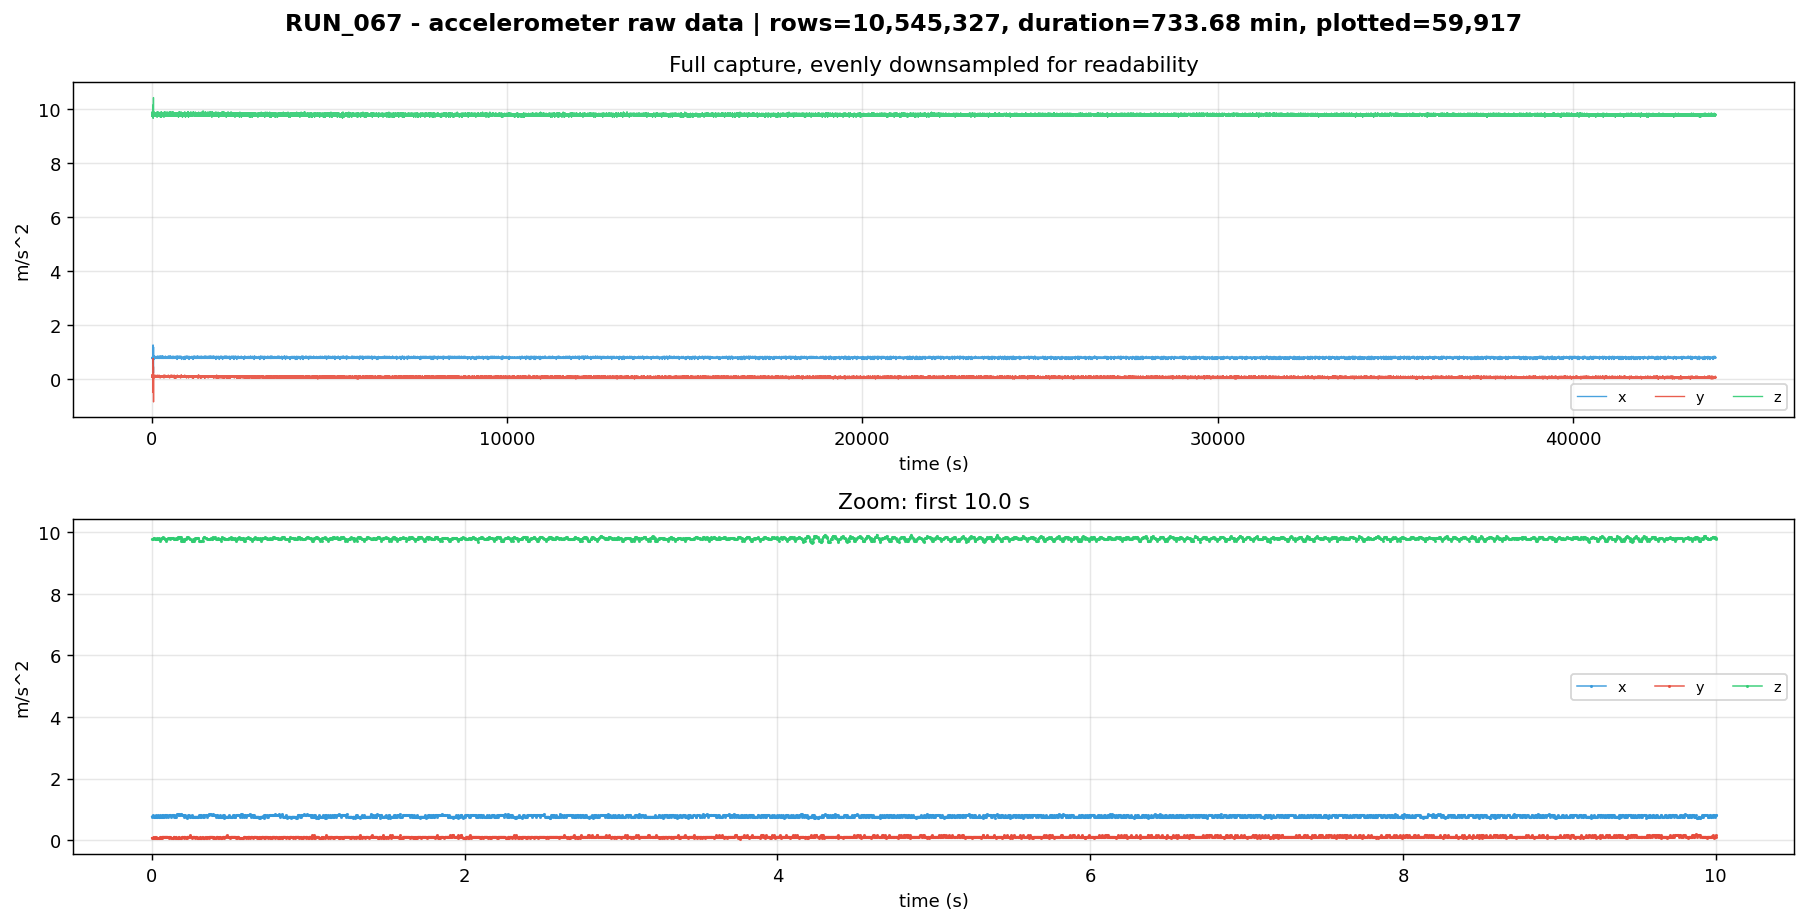

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_accelerometer_raw.png


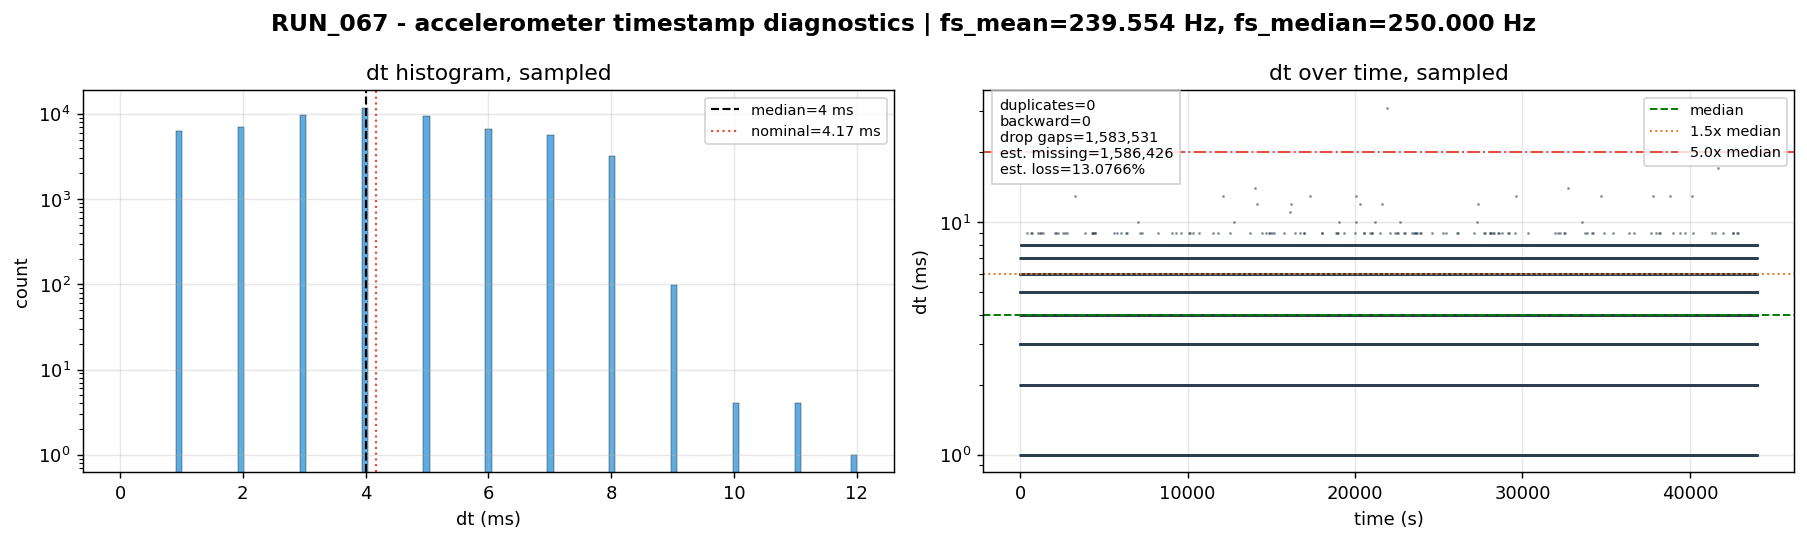

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_accelerometer_timestamp.png
    Top timestamp gaps:


,run_id,sensor,time_s,dt_ms,estimated_missing
260,067,accelerometer,43450.453,280.0,69
160,067,accelerometer,26325.987,275.0,68
220,067,accelerometer,35264.516,260.0,64
120,067,accelerometer,21821.147,193.0,47
221,067,accelerometer,36241.264,191.0,47
80,067,accelerometer,14641.123,159.0,39
100,067,accelerometer,18219.875,157.0,38
0,067,accelerometer,1075.508,131.0,32
222,067,accelerometer,37134.396,119.0,29
1,067,accelerometer,2068.623,117.0,28


  [gyroscope] file=gyroscope.csv  time_col=timestamp_ms (ms)  value_cols=['x', 'y', 'z']
    rows=4,399,149  duration=733.68 min  fs_mean=99.934 Hz  fs_median=100.000 Hz  drop_gaps=108  est_missing=533


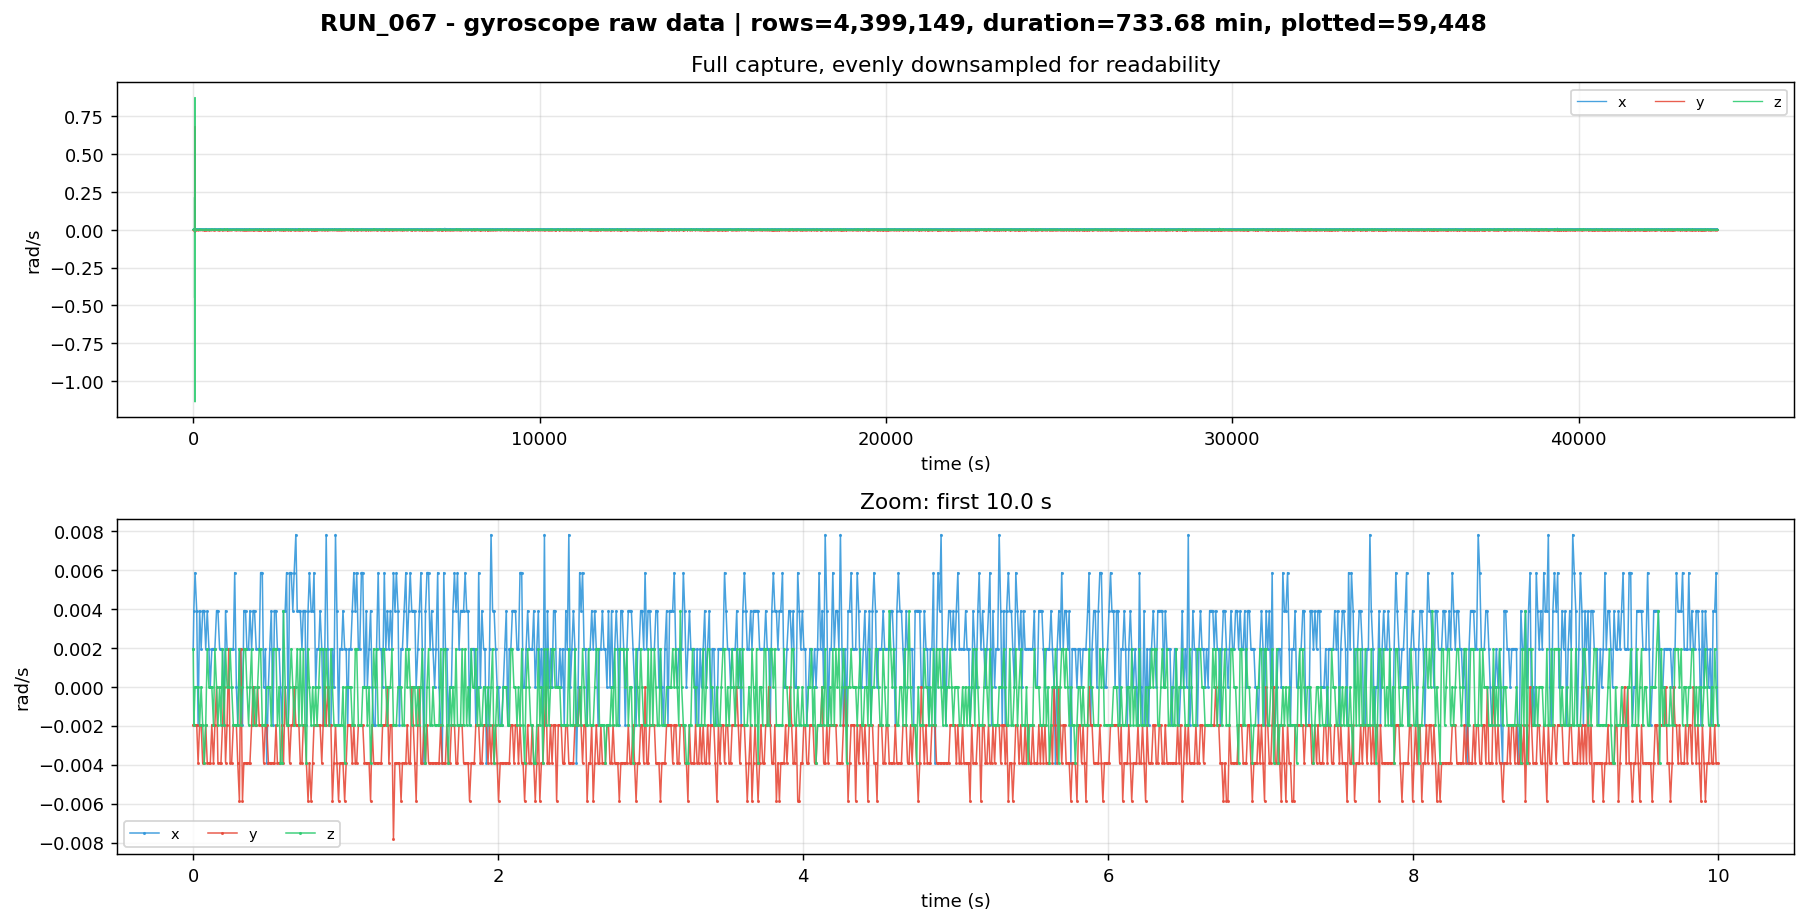

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_gyroscope_raw.png


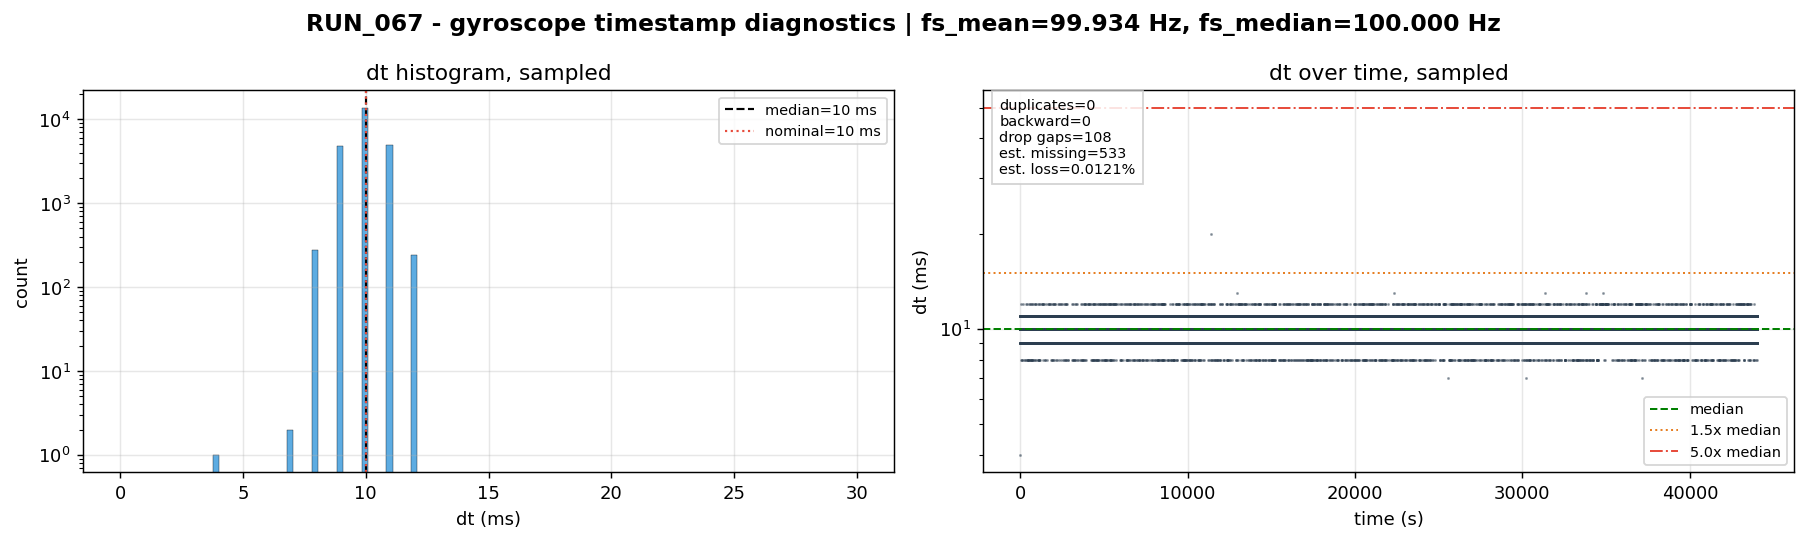

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_gyroscope_timestamp.png
    Top timestamp gaps:


,run_id,sensor,time_s,dt_ms,estimated_missing
83,067,gyroscope,43450.451,281.0,27
50,067,gyroscope,26325.993,280.0,27
66,067,gyroscope,35264.522,269.0,26
37,067,gyroscope,21821.150,200.0,19
67,067,gyroscope,36241.270,199.0,19
20,067,gyroscope,14641.131,170.0,16
38,067,gyroscope,18219.874,162.0,15
0,067,gyroscope,1075.513,140.0,13
68,067,gyroscope,37134.403,131.0,12
1,067,gyroscope,2068.624,120.0,11


  [magnetometer] file=magnetometer.csv  time_col=timestamp_ms (ms)  value_cols=['x', 'y', 'z']
    rows=4,399,148  duration=733.68 min  fs_mean=99.934 Hz  fs_median=100.000 Hz  drop_gaps=107  est_missing=534


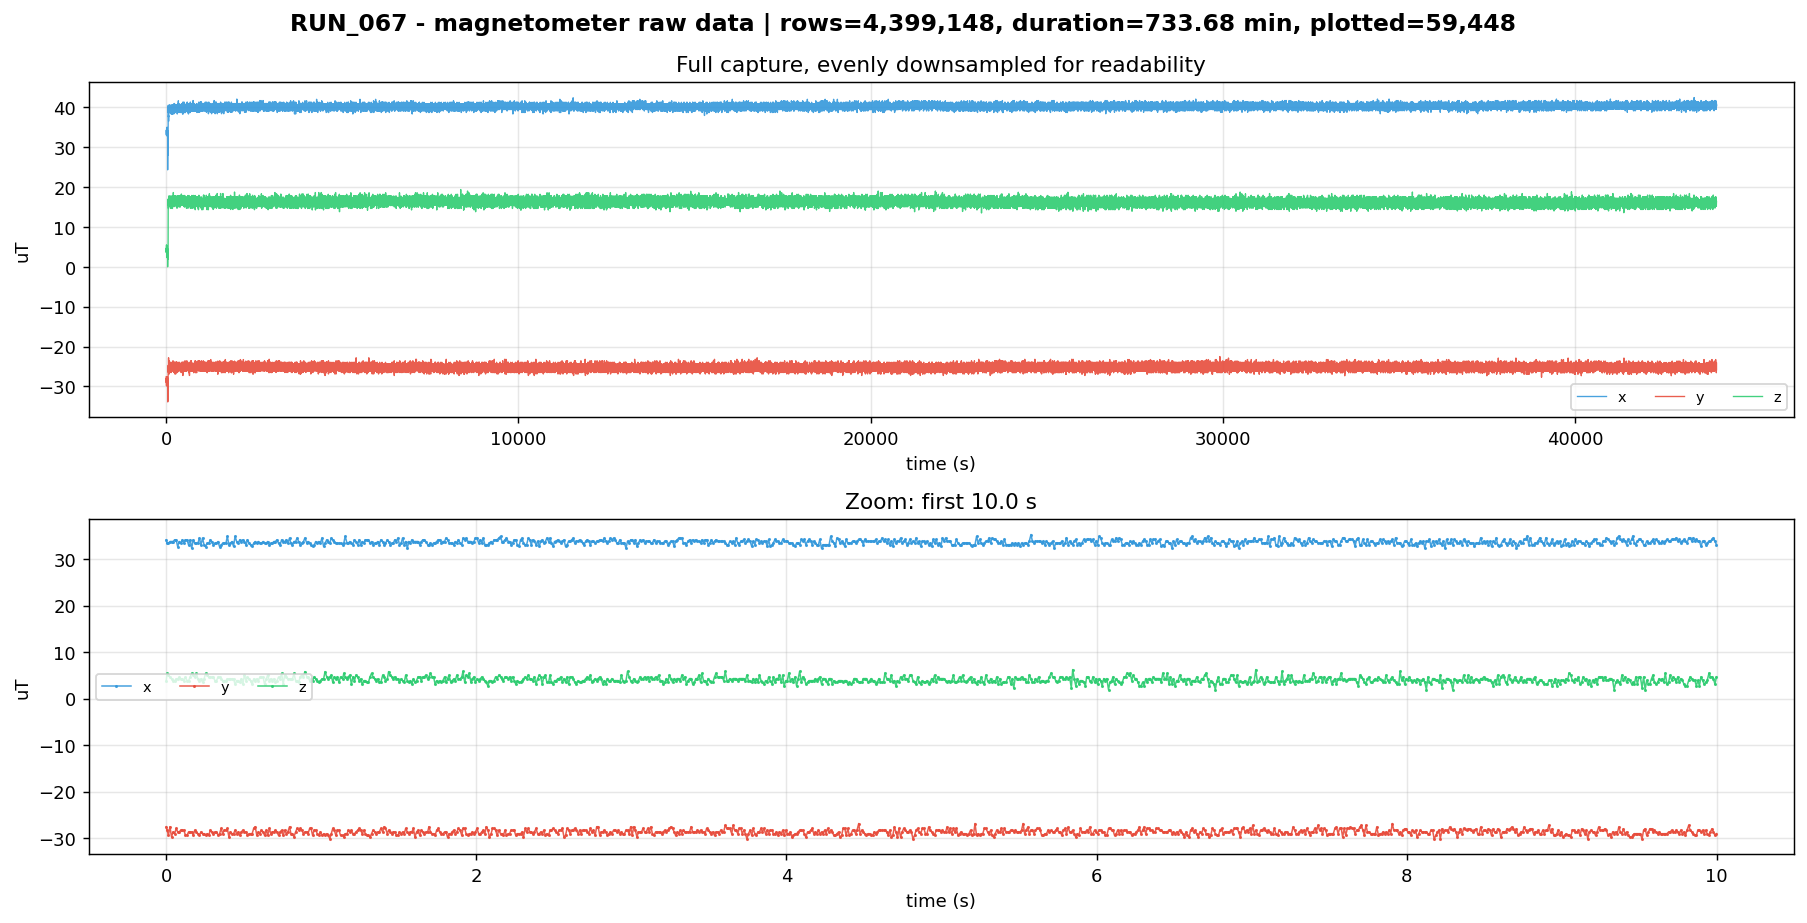

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_magnetometer_raw.png


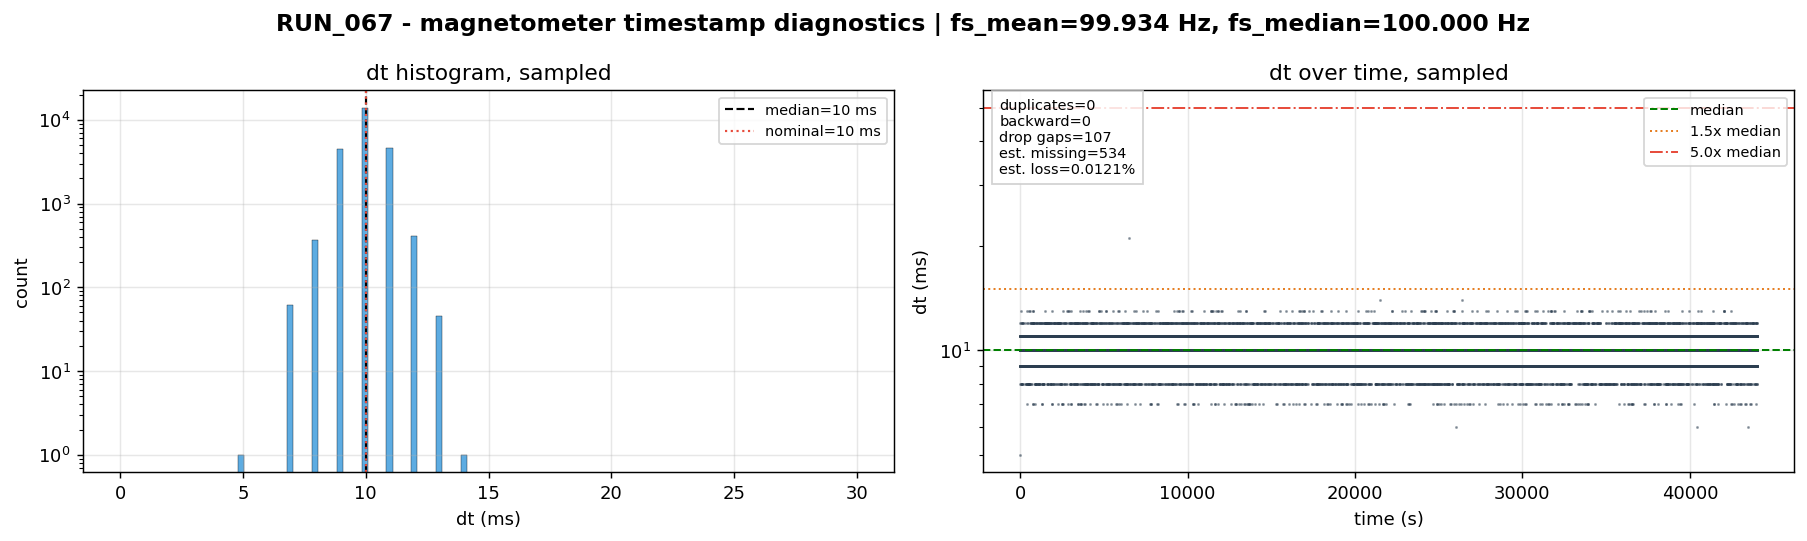

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_magnetometer_timestamp.png
    Top timestamp gaps:


,run_id,sensor,time_s,dt_ms,estimated_missing
50,067,magnetometer,26325.995,290.0,28
81,067,magnetometer,43450.453,281.0,27
64,067,magnetometer,35264.524,270.0,26
65,067,magnetometer,36241.272,200.0,19
36,067,magnetometer,21821.151,199.0,19
20,067,magnetometer,14641.133,170.0,16
37,067,magnetometer,18219.876,162.0,15
0,067,magnetometer,1075.515,141.0,13
1,067,magnetometer,2970.722,121.0,11
66,067,magnetometer,37134.394,121.0,11


  [microphone] file=microphone.csv  time_col=timestamp_ms (ms)  value_cols=['value']
    rows=44,015,261  duration=733.68 min  fs_mean=999.879 Hz  fs_median=1000.000 Hz  drop_gaps=114  est_missing=5,335


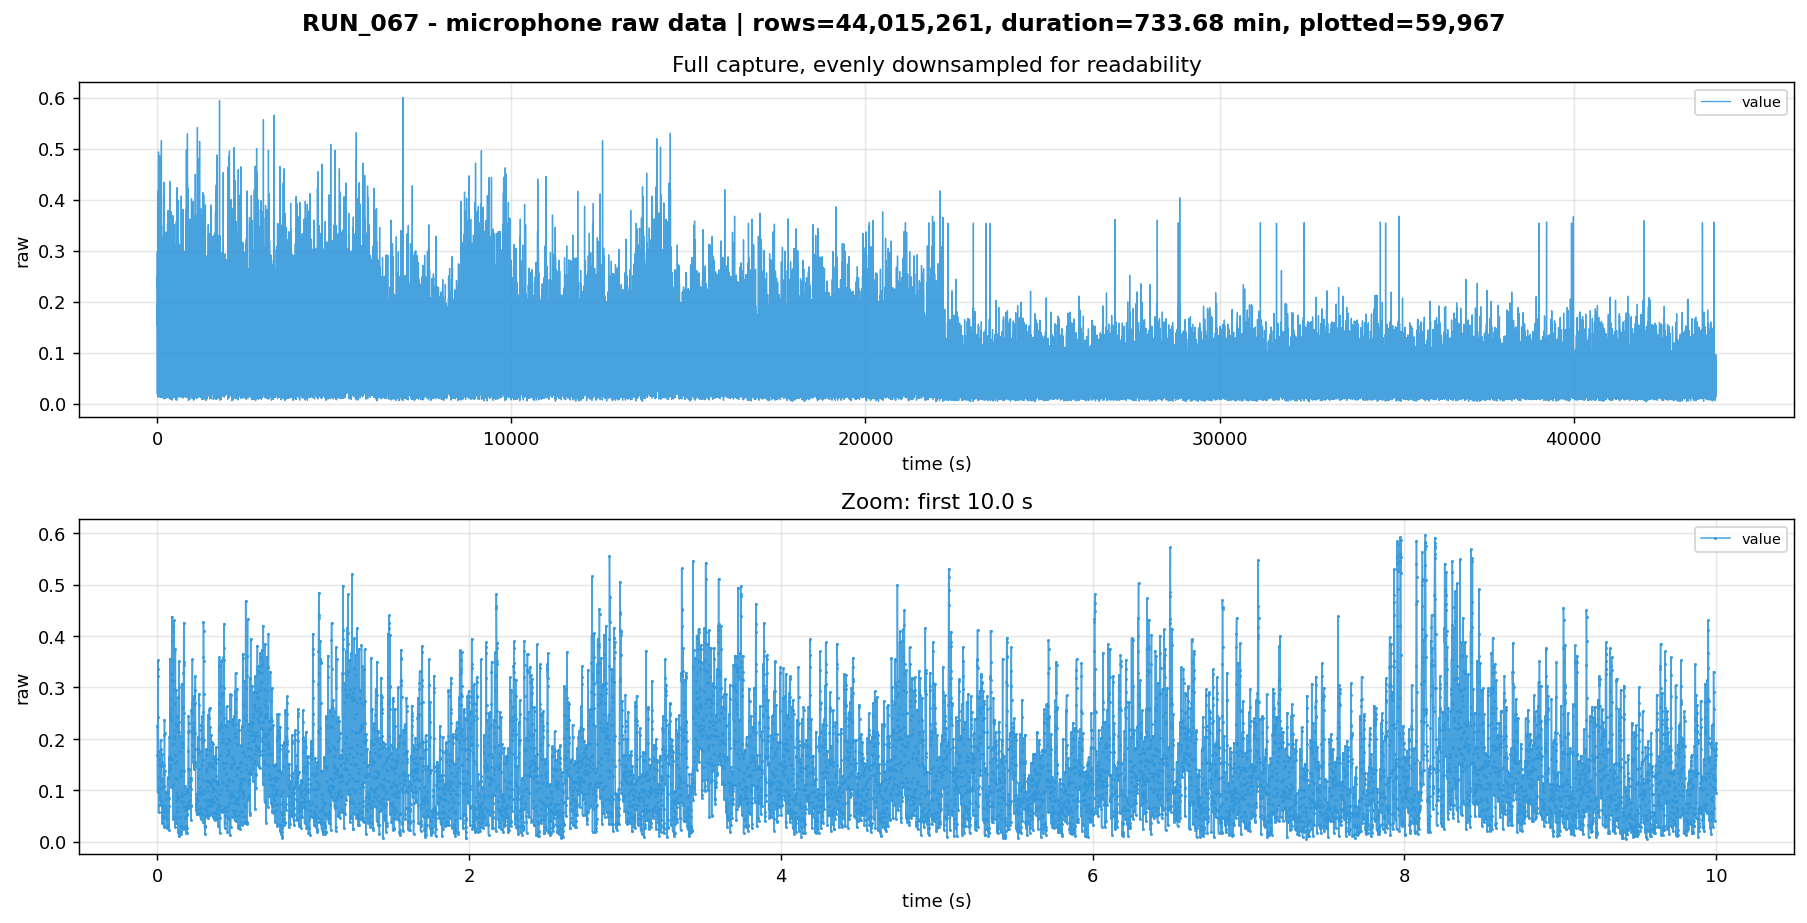

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_microphone_raw.png


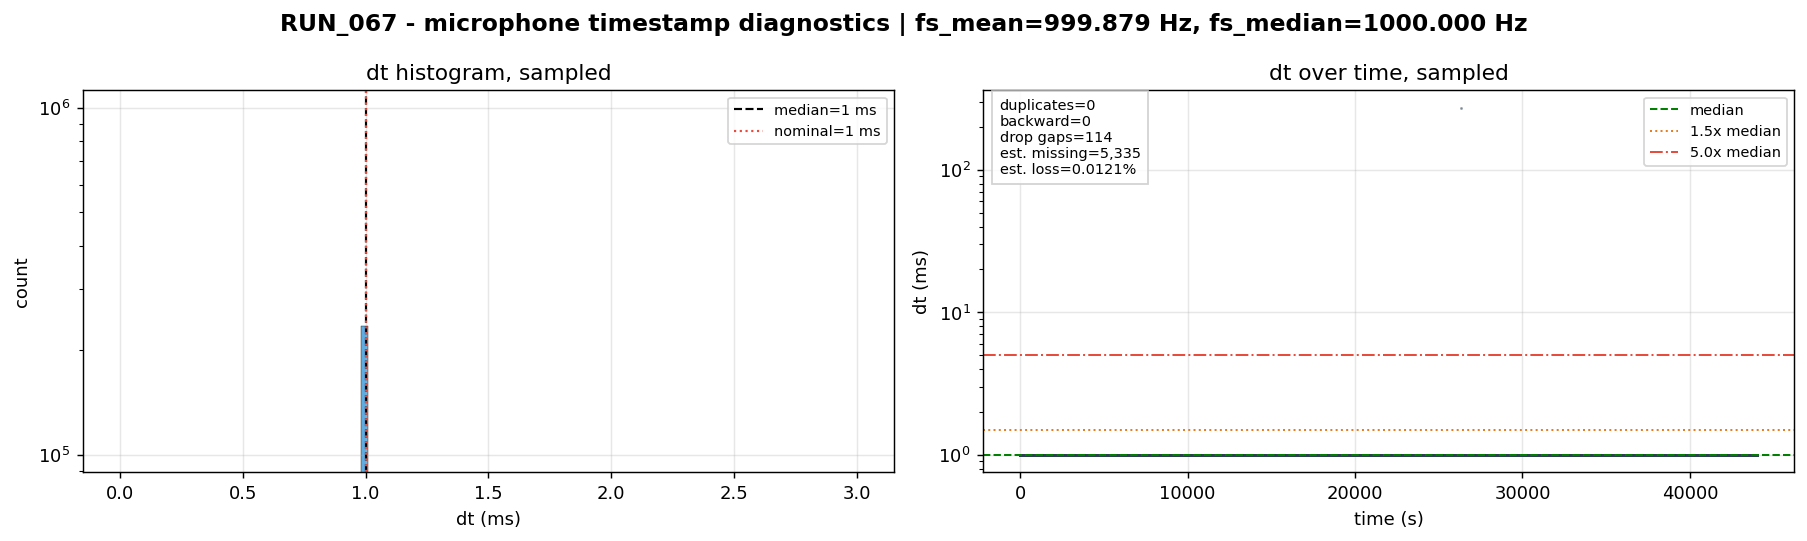

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_microphone_timestamp.png
    Top timestamp gaps:


,run_id,sensor,time_s,dt_ms,estimated_missing
111,067,microphone,43450.451,276.0,275
78,067,microphone,26325.986,273.0,272
94,067,microphone,35264.516,259.0,258
99,067,microphone,36241.263,190.0,189
68,067,microphone,21821.145,187.0,186
53,067,microphone,14641.123,157.0,156
62,067,microphone,18219.871,151.0,150
4,067,microphone,1075.507,127.0,126
102,067,microphone,37134.394,117.0,116
8,067,microphone,2068.620,114.0,113


  [vibration] file=vibration.csv  time_col=timestamp_ms (ms)  value_cols=['value']
    rows=44,015,301  duration=733.68 min  fs_mean=999.880 Hz  fs_median=1000.000 Hz  drop_gaps=113  est_missing=5,295


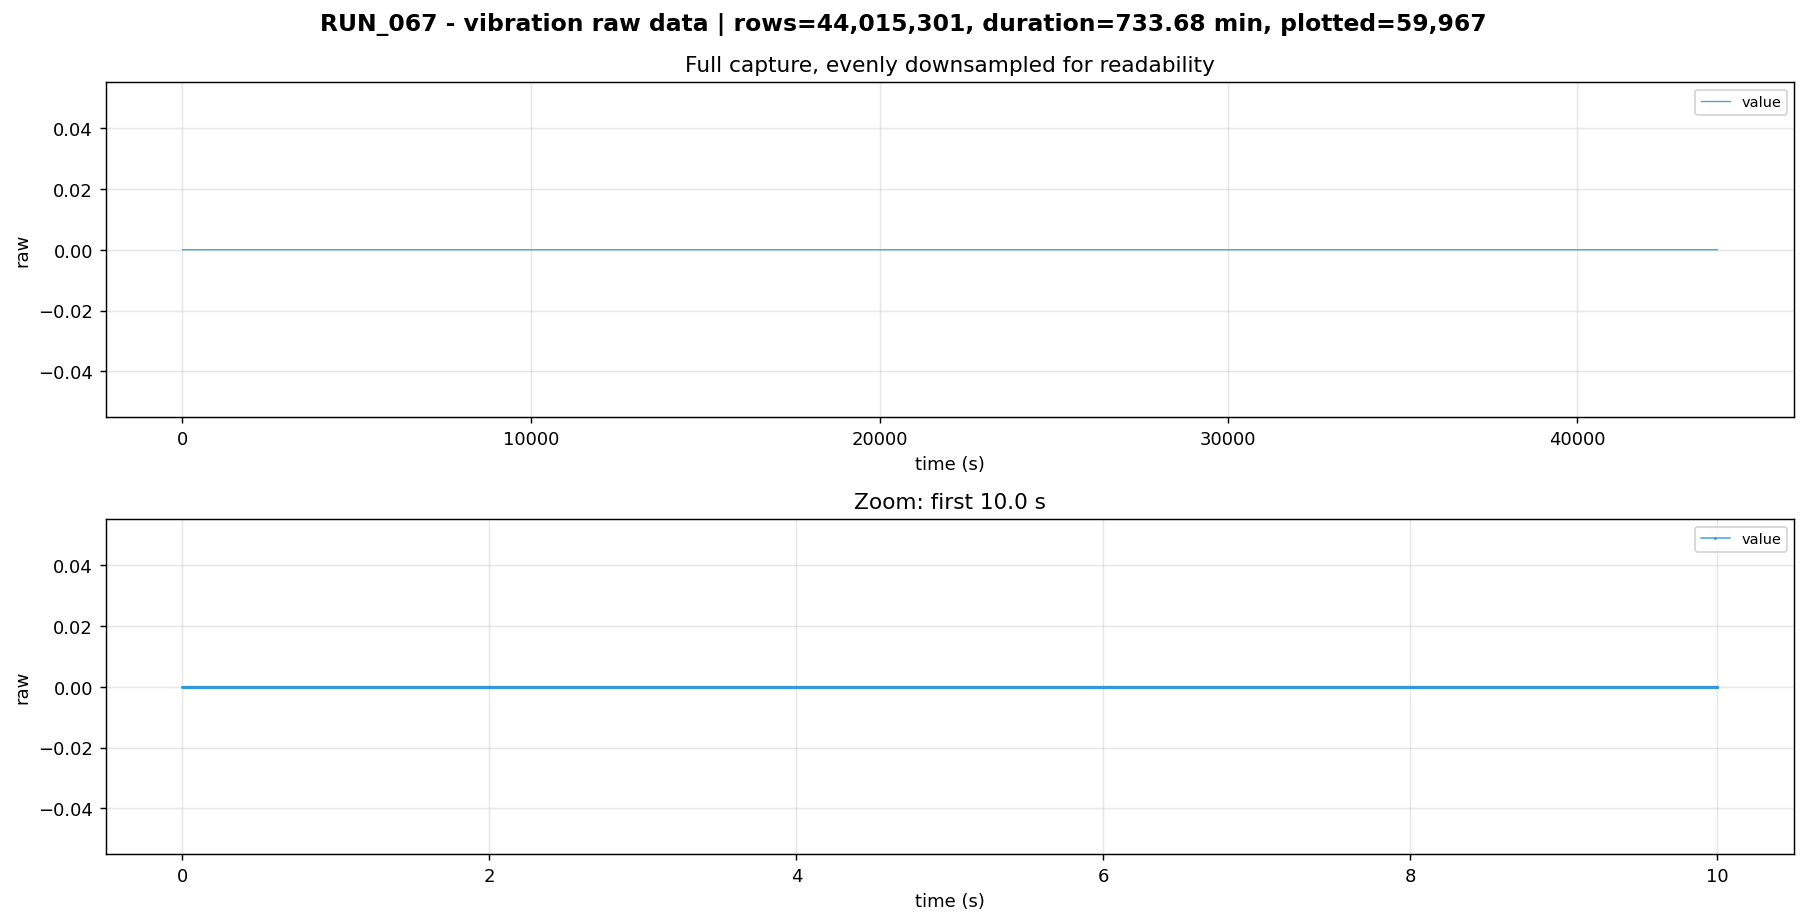

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_vibration_raw.png


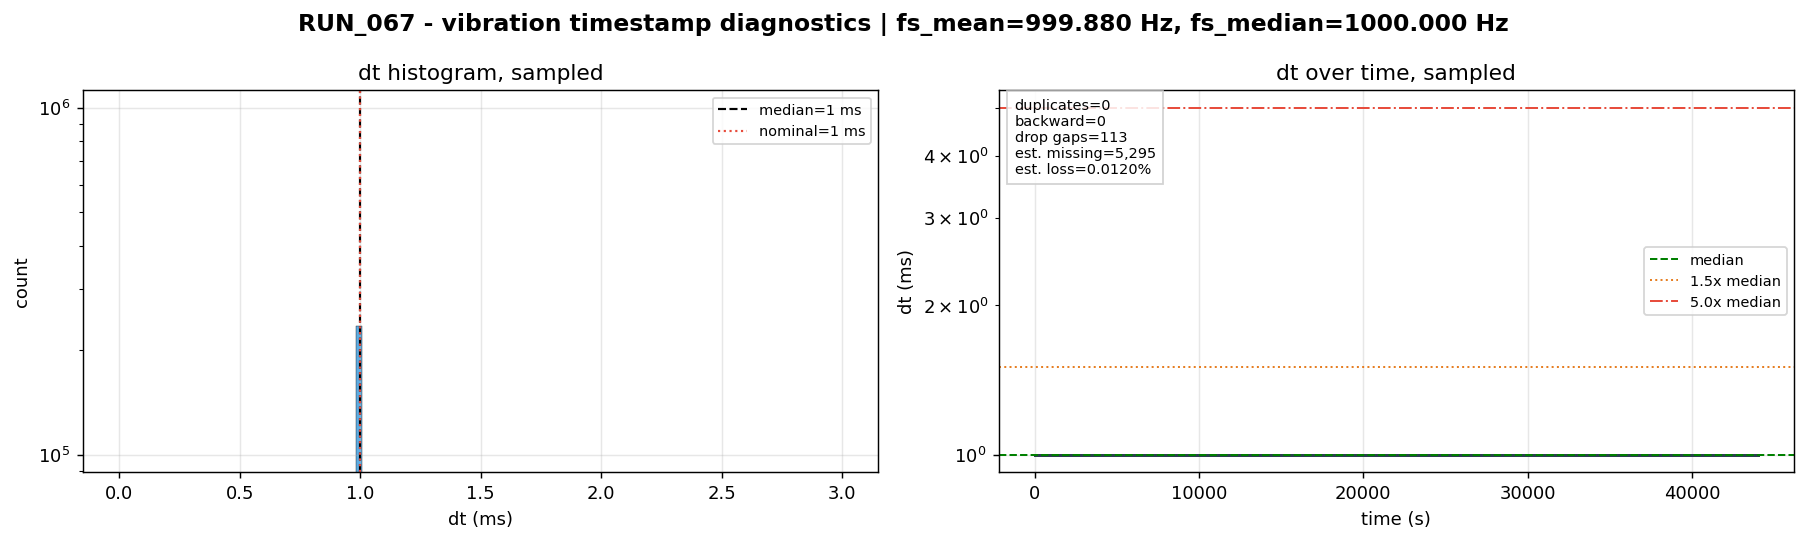

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_vibration_timestamp.png
    Top timestamp gaps:


,run_id,sensor,time_s,dt_ms,estimated_missing
110,067,vibration,43450.451,275.0,274
77,067,vibration,26325.986,272.0,271
93,067,vibration,35264.517,260.0,259
98,067,vibration,36241.263,189.0,188
67,067,vibration,21821.145,186.0,185
52,067,vibration,14641.123,157.0,156
61,067,vibration,18219.872,152.0,151
4,067,vibration,1075.507,127.0,126
101,067,vibration,37134.394,117.0,116
8,067,vibration,2068.620,113.0,112


  [photodiode] file=photodiode.csv  time_col=timestamp_ms (ms)  value_cols=['value']
    rows=14,397,088  duration=1200.00 min  fs_mean=199.960 Hz  fs_median=200.000 Hz  drop_gaps=413  est_missing=2,914


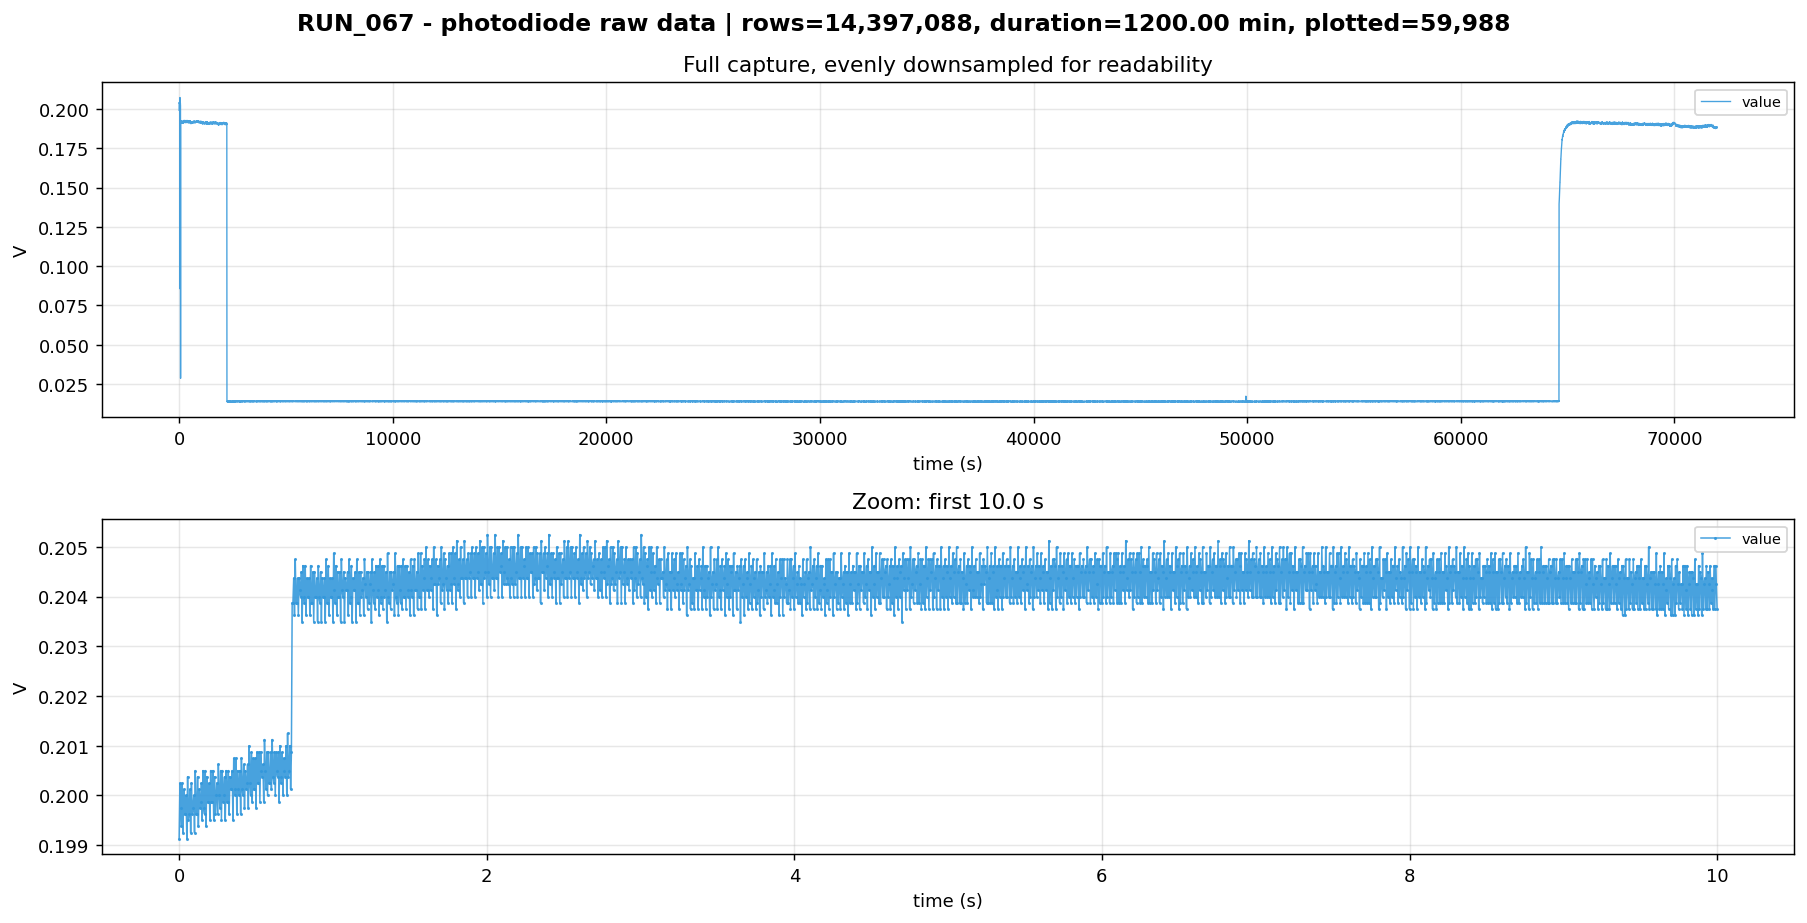

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_photodiode_raw.png


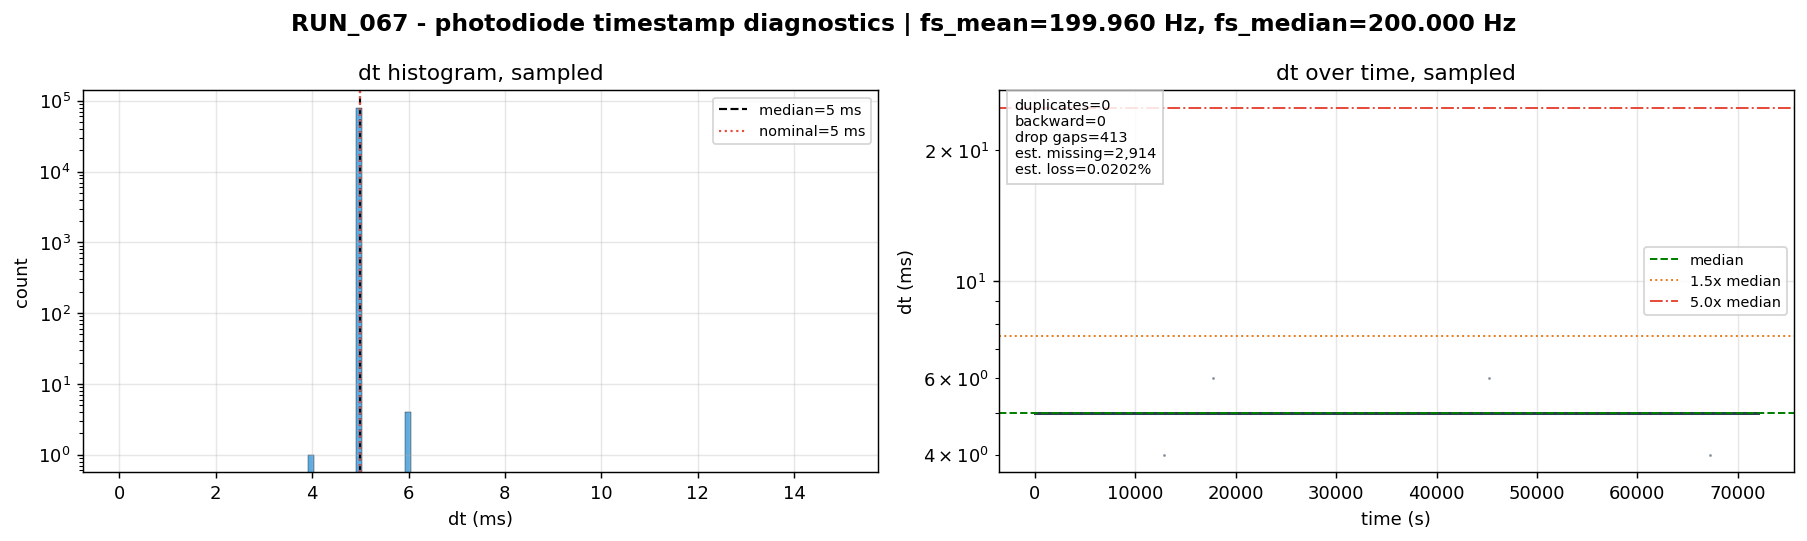

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_photodiode_timestamp.png
    Top timestamp gaps:


,run_id,sensor,time_s,dt_ms,estimated_missing
218,067,photodiode,43450.450,305.0,60
140,067,photodiode,26325.985,300.0,59
180,067,photodiode,35264.515,260.0,51
249,067,photodiode,51305.040,250.0,49
181,067,photodiode,36241.260,220.0,43
100,067,photodiode,21821.145,215.0,42
60,067,photodiode,14641.120,185.0,36
80,067,photodiode,18219.870,185.0,36
0,067,photodiode,1075.530,180.0,35
182,067,photodiode,37134.410,170.0,33


  [pressure] file=pressure.csv  time_col=timestamp_ms (ms)  value_cols=['value']
    rows=3,599,227  duration=1200.00 min  fs_mean=49.989 Hz  fs_median=50.000 Hz  drop_gaps=325  est_missing=773


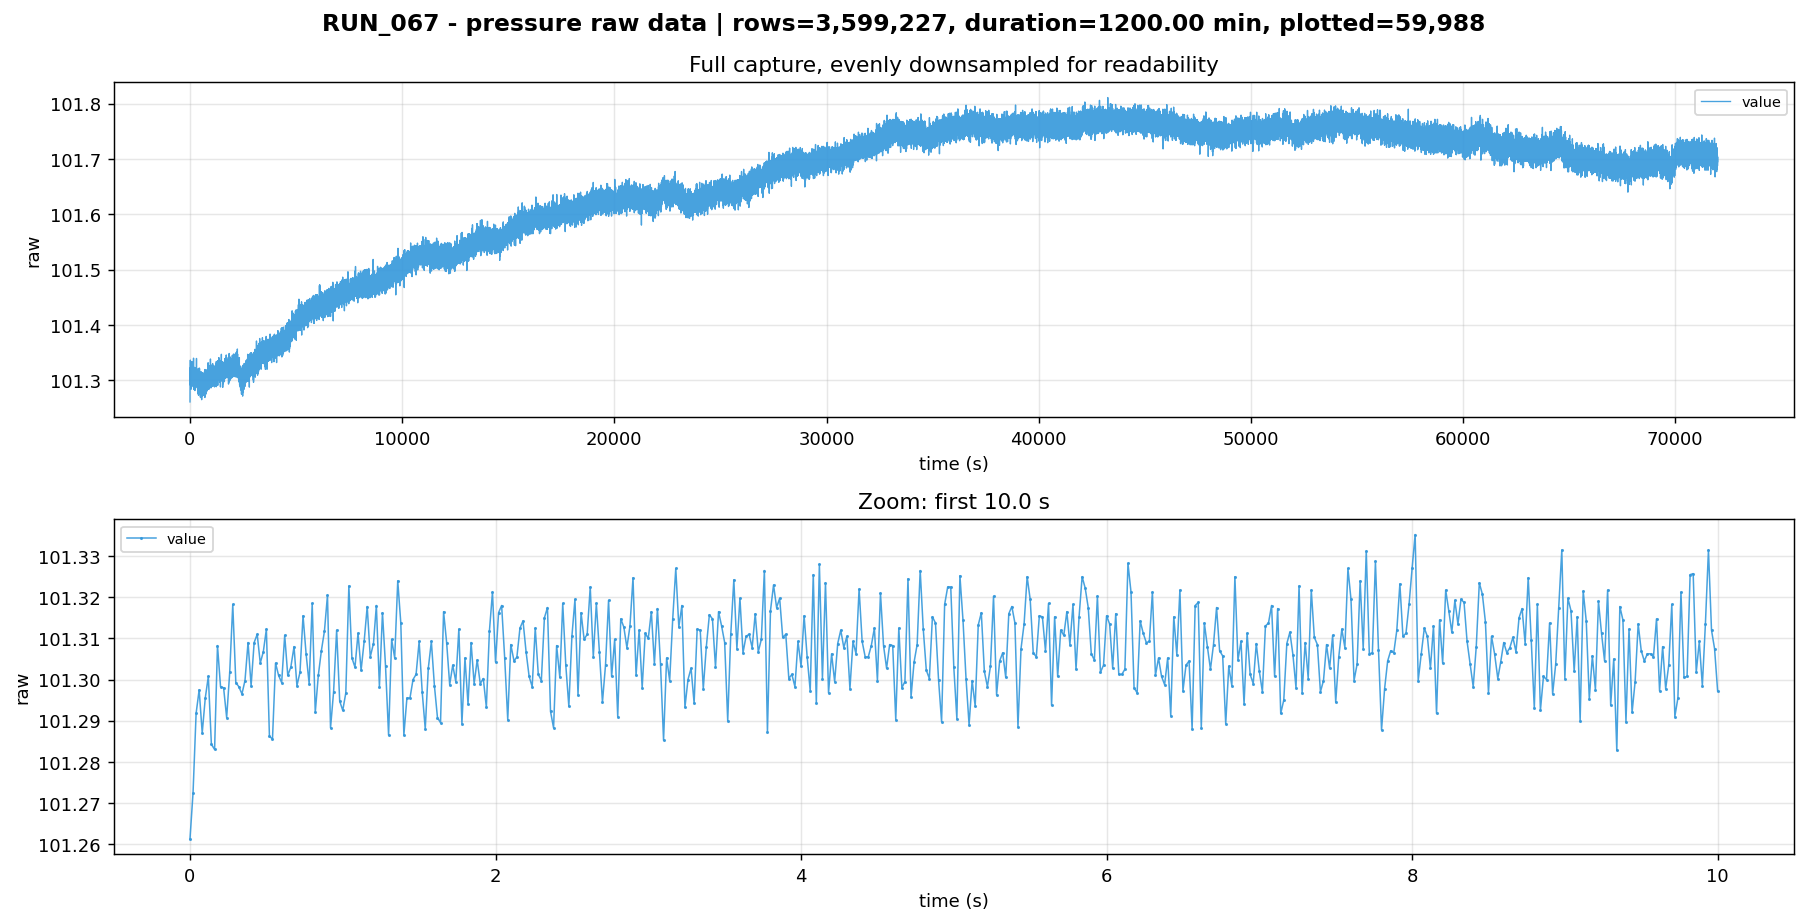

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_pressure_raw.png


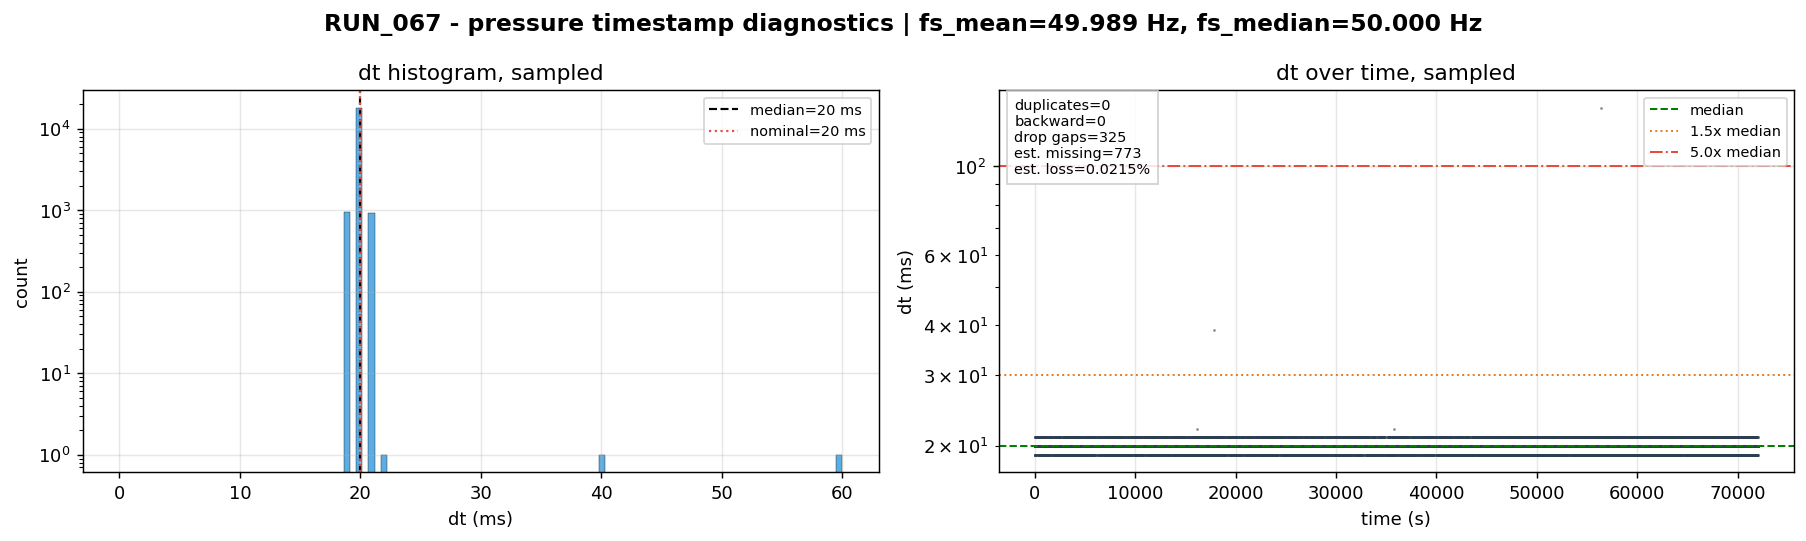

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_pressure_timestamp.png
    Top timestamp gaps:


,run_id,sensor,time_s,dt_ms,estimated_missing
20,067,pressure,26325.980,320.0,15
40,067,pressure,43450.440,320.0,15
60,067,pressure,51305.040,280.0,13
41,067,pressure,35264.500,260.0,12
21,067,pressure,21821.140,240.0,11
42,067,pressure,36241.260,240.0,11
0,067,pressure,14641.120,220.0,10
1,067,pressure,1075.520,200.0,9
22,067,pressure,18219.860,200.0,9
2,067,pressure,2098.301,181.0,8


  [temperature] file=temperature.csv  time_col=timestamp_ms (ms)  value_cols=['value']
    rows=3,599,182  duration=1200.00 min  fs_mean=49.989 Hz  fs_median=50.000 Hz  drop_gaps=330  est_missing=819


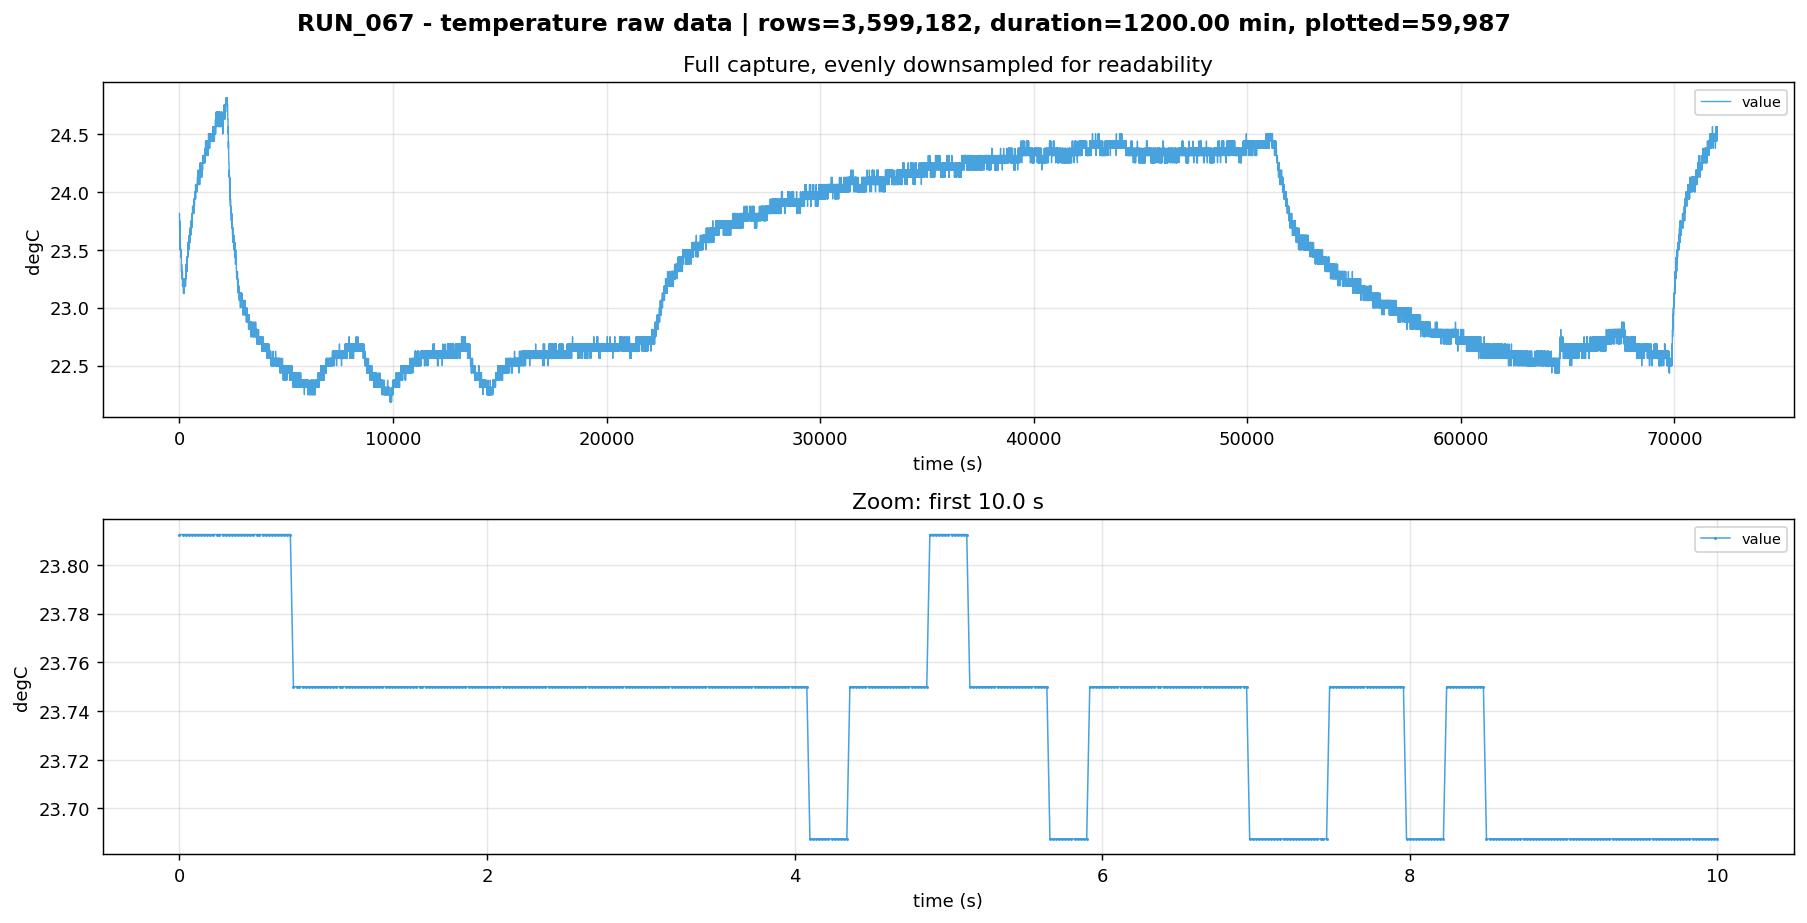

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_temperature_raw.png


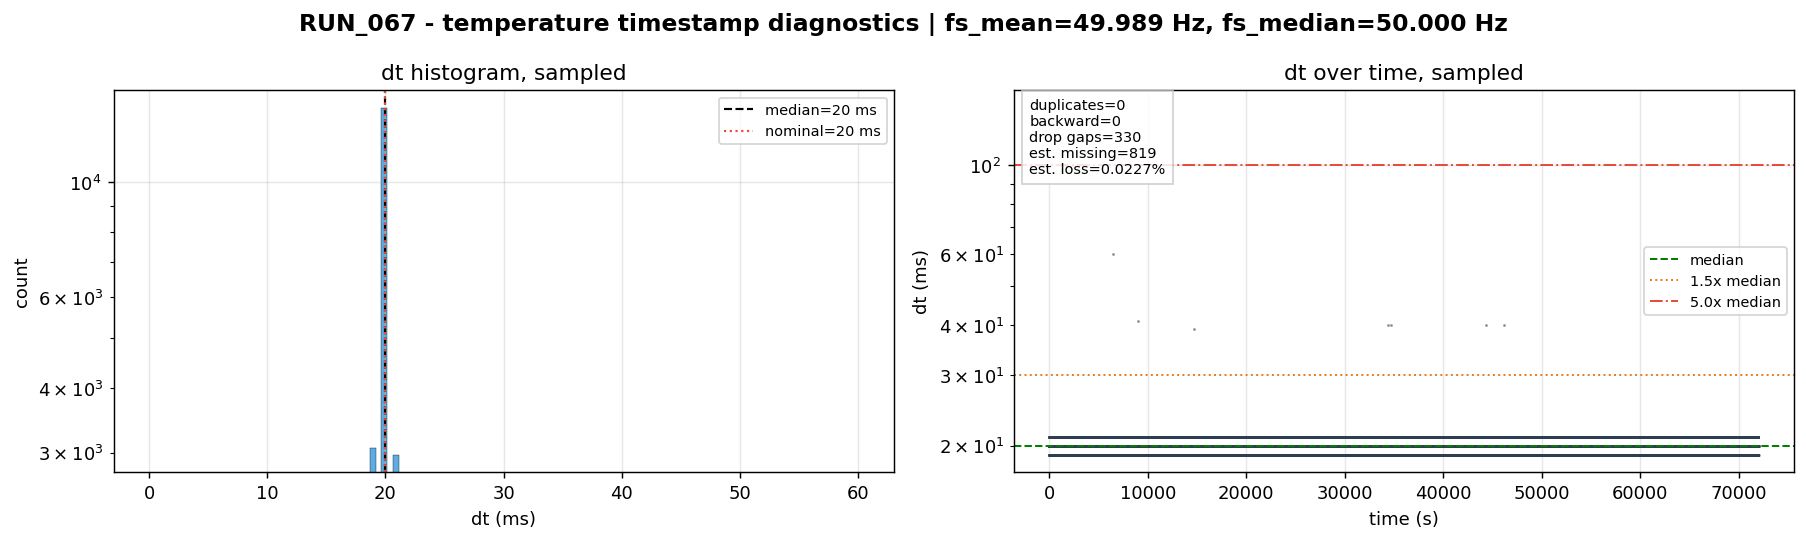

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_temperature_timestamp.png
    Top timestamp gaps:


,run_id,sensor,time_s,dt_ms,estimated_missing
20,067,temperature,26326.000,320.0,15
40,067,temperature,43450.461,320.0,15
60,067,temperature,51305.060,279.0,13
41,067,temperature,35264.521,260.0,12
21,067,temperature,21821.161,240.0,11
42,067,temperature,36241.281,240.0,11
0,067,temperature,14641.141,220.0,10
22,067,temperature,18219.881,201.0,9
1,067,temperature,1075.540,200.0,9
2,067,temperature,2098.321,180.0,8


  [current] file=current.csv  time_col=timestamp_ms (ms)  value_cols=['value']
    rows=14,397,090  duration=1200.00 min  fs_mean=199.960 Hz  fs_median=200.000 Hz  drop_gaps=415  est_missing=2,912


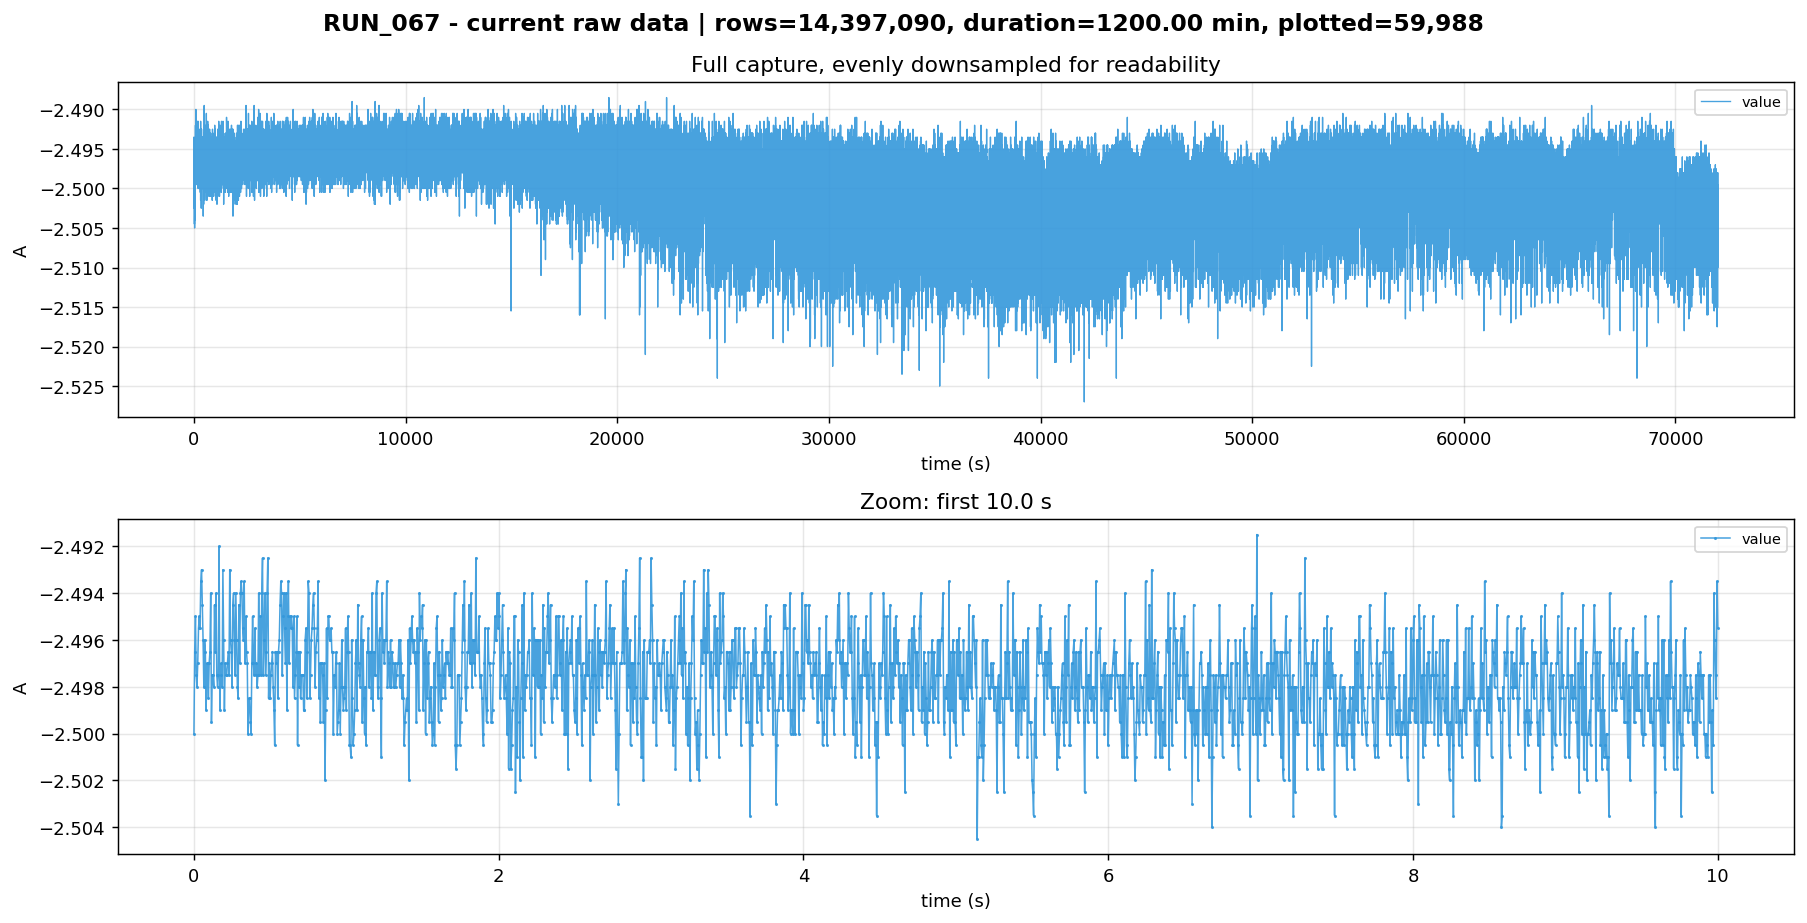

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_current_raw.png


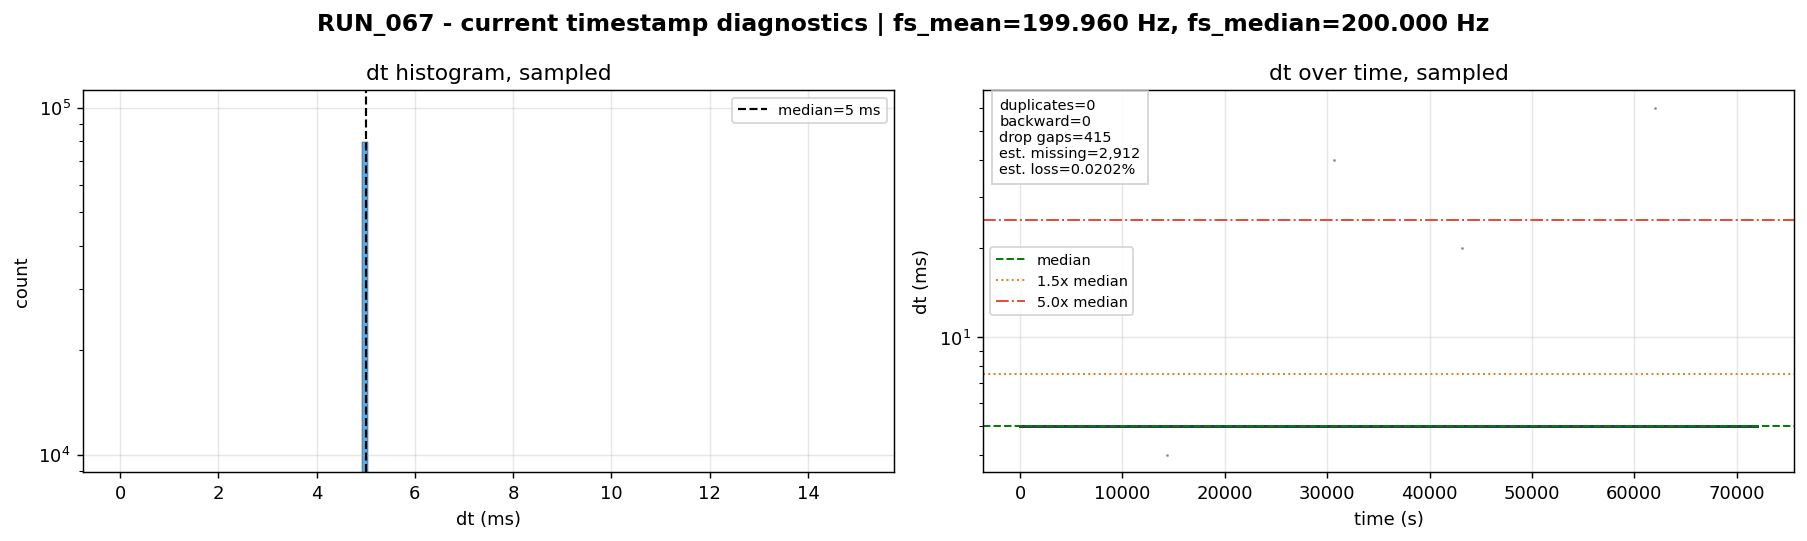

    saved figure: /content/drive/MyDrive/sensor_initial_analysis_outputs/RUN_067/RUN_067_current_timestamp.png
    Top timestamp gaps:


,run_id,sensor,time_s,dt_ms,estimated_missing
217,067,current,43450.450,305.0,60
140,067,current,26325.985,300.0,59
180,067,current,35264.515,260.0,51
248,067,current,51305.045,255.0,50
181,067,current,36241.265,220.0,43
100,067,current,21821.145,215.0,42
60,067,current,14641.125,190.0,37
80,067,current,18219.870,185.0,36
0,067,current,1075.530,180.0,35
262,067,current,58093.390,170.0,33



Timestamp summary


,run_id,sensor,status,file,rows_read,valid_timestamp_rows,valid_data_rows,duration_s,duration_min,duration_hr,...,drop_gap_count,large_gap_threshold_ms,large_gap_count,estimated_missing_by_median,estimated_loss_pct_by_median,expected_samples_nominal,missing_vs_nominal_estimate,time_unit,timestamp_column,value_columns
0,067,accelerometer,ok,/content/drive/MyDrive/capstone_data/UNIT_0001...,10545327,10545327,10545327,44020.590,733.676500,12.227942,...,1583531,20.0,79,1586426,13.076643,10564942.60,19616.0,ms,timestamp_ms,"x,y,z"
1,067,gyroscope,ok,/content/drive/MyDrive/capstone_data/UNIT_0001...,4399149,4399149,4399149,44020.592,733.676533,12.227942,...,108,50.0,35,533,0.012115,4402060.20,2911.0,ms,timestamp_ms,"x,y,z"
2,067,magnetometer,ok,/content/drive/MyDrive/capstone_data/UNIT_0001...,4399148,4399148,4399148,44020.594,733.676567,12.227943,...,107,50.0,36,534,0.012137,4402060.40,2912.0,ms,timestamp_ms,"x,y,z"
3,067,microphone,ok,/content/drive/MyDrive/capstone_data/UNIT_0001...,44015261,44015261,44015261,44020.595,733.676583,12.227943,...,114,5.0,102,5335,0.012119,44020596.00,5335.0,ms,timestamp_ms,value
4,067,vibration,ok,/content/drive/MyDrive/capstone_data/UNIT_0001...,44015301,44015301,44015301,44020.595,733.676583,12.227943,...,113,5.0,102,5295,0.012028,44020596.00,5295.0,ms,timestamp_ms,value
5,067,photodiode,ok,/content/drive/MyDrive/capstone_data/UNIT_0001...,14397088,14397088,14397088,72000.005,1200.000083,20.000001,...,413,25.0,182,2914,0.020236,14400002.00,2914.0,ms,timestamp_ms,value
6,067,pressure,ok,/content/drive/MyDrive/capstone_data/UNIT_0001...,3599227,3599227,3599227,71999.980,1199.999667,19.999994,...,325,100.0,44,773,0.021472,3600000.00,773.0,ms,timestamp_ms,value
7,067,temperature,ok,/content/drive/MyDrive/capstone_data/UNIT_0001...,3599182,3599182,3599182,72000.001,1200.000017,20.000000,...,330,100.0,48,819,0.022750,3600001.05,819.0,ms,timestamp_ms,value
8,067,current,ok,/content/drive/MyDrive/capstone_data/UNIT_0001...,14397090,14397090,14397090,72000.005,1200.000083,20.000001,...,415,25.0,181,2912,0.020222,NaN,NaN,ms,timestamp_ms,value



Value summary


,run_id,sensor,channel,unit,n,mean,std,rms,min,max,peak_to_peak
0,067,accelerometer,x,m/s^2,10545327,0.787243,0.022485,0.787564,-6.207031,3.714844,9.921875
1,067,accelerometer,y,m/s^2,10545327,0.071676,0.020691,0.074602,-2.375000,6.589844,8.964844
2,067,accelerometer,z,m/s^2,10545327,9.780019,0.031450,9.780070,2.871094,24.093750,21.222656
3,067,gyroscope,x,rad/s,4399149,0.002045,0.002256,0.003045,-0.429688,0.300781,0.730469
4,067,gyroscope,y,rad/s,4399149,-0.003459,0.002343,0.004178,-1.218750,0.978516,2.197266
5,067,gyroscope,z,rad/s,4399149,-0.000405,0.004683,0.004701,-1.751953,0.945312,2.697266
6,067,magnetometer,x,uT,4399148,40.207234,0.576756,40.211370,20.250000,42.812500,22.562500
7,067,magnetometer,y,uT,4399148,-25.215243,0.620174,25.222868,-34.250000,-21.000000,13.250000
8,067,magnetometer,z,uT,4399148,16.199825,0.820594,16.220595,-1.937500,19.875000,21.812500
9,067,microphone,value,raw,44015261,0.075797,0.064390,0.099455,0.001159,0.703917,0.702758



Largest timestamp gaps across all sensors


,run_id,sensor,time_s,dt_ms,estimated_missing
0,067,accelerometer,43450.453,280.0,69
1,067,accelerometer,26325.987,275.0,68
2,067,accelerometer,35264.516,260.0,64
3,067,accelerometer,21821.147,193.0,47
4,067,accelerometer,36241.264,191.0,47
...,...,...,...,...,...
95,067,vibration,19978.417,101.0,100
96,067,vibration,3411.206,96.0,95
97,067,vibration,6285.198,90.0,89
98,067,vibration,16195.372,89.0,88



Saved summaries:
  /content/drive/MyDrive/sensor_initial_analysis_outputs/all_sensor_timestamp_summary.csv
  /content/drive/MyDrive/sensor_initial_analysis_outputs/all_sensor_value_summary.csv
  /content/drive/MyDrive/sensor_initial_analysis_outputs/all_sensor_gap_summary.csv


In [5]:
all_timestamp_rows = []
all_value_rows = []
all_gap_rows = []
all_results = []

for run_id in RUN_IDS:
    print('\n' + '=' * 72)
    print(f'RUN_{run_id}')
    print('=' * 72)
    run_out_dir = Path(OUTPUT_ROOT) / f'RUN_{run_id}'
    run_out_dir.mkdir(parents=True, exist_ok=True)

    for cfg in SENSORS:
        result = analyze_sensor_file(run_id, cfg)
        all_results.append(result)
        all_timestamp_rows.append(result['timestamp_summary'])
        all_value_rows.extend(result.get('value_summary', []))

        if result.get('status') == 'ok':
            plot_raw(result, run_out_dir)
            plot_timestamp(result, run_out_dir)
            if not result['top_gaps'].empty:
                all_gap_rows.append(result['top_gaps'])
                print('    Top timestamp gaps:')
                display(result['top_gaps'].round(4))

timestamp_summary_df = pd.DataFrame(all_timestamp_rows)
value_summary_df = pd.DataFrame(all_value_rows)
gap_summary_df = pd.concat(all_gap_rows, ignore_index=True) if all_gap_rows else pd.DataFrame()

print('\nTimestamp summary')
display(timestamp_summary_df)

print('\nValue summary')
display(value_summary_df)

if not gap_summary_df.empty:
    print('\nLargest timestamp gaps across all sensors')
    display(gap_summary_df.sort_values(['run_id', 'sensor', 'dt_ms'], ascending=[True, True, False]).round(4))

if SAVE_SUMMARIES:
    out_root = Path(OUTPUT_ROOT)
    out_root.mkdir(parents=True, exist_ok=True)
    ts_path = out_root / 'all_sensor_timestamp_summary.csv'
    val_path = out_root / 'all_sensor_value_summary.csv'
    gap_path = out_root / 'all_sensor_gap_summary.csv'
    timestamp_summary_df.to_csv(ts_path, index=False)
    value_summary_df.to_csv(val_path, index=False)
    if not gap_summary_df.empty:
        gap_summary_df.to_csv(gap_path, index=False)
    print('\nSaved summaries:')
    print(f'  {ts_path}')
    print(f'  {val_path}')
    if not gap_summary_df.empty:
        print(f'  {gap_path}')

## 5. Quick Quality Flags

This cell turns the timestamp table into a compact pass/warn view.

In [6]:
def build_quality_flags(timestamp_df):
    rows = []
    for _, r in timestamp_df.iterrows():
        flags = []
        status = r.get('status')
        if status != 'ok':
            flags.append(status)
        else:
            if r.get('duplicate_timestamps', 0) > 0:
                flags.append('duplicate timestamps')
            if r.get('backward_timestamps', 0) > 0:
                flags.append('backward timestamps')
            if r.get('drop_gap_count', 0) > 0:
                flags.append('possible dropped samples')
            if pd.notna(r.get('fs_vs_nominal_pct')) and abs(r.get('fs_vs_nominal_pct')) > 5:
                flags.append('fs differs from nominal >5%')
            if pd.notna(r.get('estimated_loss_pct_by_median')) and r.get('estimated_loss_pct_by_median') > 0.1:
                flags.append('estimated loss >0.1%')
        rows.append({
            'run_id': r.get('run_id'),
            'sensor': r.get('sensor'),
            'status': 'PASS' if not flags else 'WARN',
            'flags': '; '.join(flags) if flags else '',
            'fs_mean_hz': r.get('fs_mean_hz'),
            'fs_median_hz': r.get('fs_median_hz'),
            'drop_gap_count': r.get('drop_gap_count'),
            'estimated_missing_by_median': r.get('estimated_missing_by_median'),
            'estimated_loss_pct_by_median': r.get('estimated_loss_pct_by_median'),
        })
    return pd.DataFrame(rows)


quality_df = build_quality_flags(timestamp_summary_df)
display(quality_df)

if SAVE_SUMMARIES:
    q_path = Path(OUTPUT_ROOT) / 'all_sensor_quality_flags.csv'
    quality_df.to_csv(q_path, index=False)
    print(f'saved: {q_path}')

,run_id,sensor,status,flags,fs_mean_hz,fs_median_hz,drop_gap_count,estimated_missing_by_median,estimated_loss_pct_by_median
0,067,accelerometer,WARN,possible dropped samples; estimated loss >0.1%,239.554399,250.0,1583531,1586426,13.076643
1,067,gyroscope,WARN,possible dropped samples,99.933867,100.0,108,533,0.012115
2,067,magnetometer,WARN,possible dropped samples,99.933840,100.0,107,534,0.012137
3,067,microphone,WARN,possible dropped samples,999.878807,1000.0,114,5335,0.012119
4,067,vibration,WARN,possible dropped samples,999.879715,1000.0,113,5295,0.012028
5,067,photodiode,WARN,possible dropped samples,199.959528,200.0,413,2914,0.020236
6,067,pressure,WARN,possible dropped samples,49.989264,50.0,325,773,0.021472
7,067,temperature,WARN,possible dropped samples,49.988624,50.0,330,819,0.022750
8,067,current,WARN,possible dropped samples,199.959556,200.0,415,2912,0.020222


saved: /content/drive/MyDrive/sensor_initial_analysis_outputs/all_sensor_quality_flags.csv
